# 💼 Job Market & Career Intelligence

## Data Science Job Market Analysis using Python & Machine Learning

This project analyzes job-market data to identify hiring patterns,
in-demand skills, salary trends, experience requirements, and
career intelligence insights.

The project combines exploratory data analysis, feature engineering,
machine learning, and business-oriented interpretation.

## Import Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Job Market Dataset

In [2]:
from pathlib import Path

# Resolve project paths so the notebook is portable across machines.
CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

if not (PROJECT_DIR / "data").exists() and (PROJECT_DIR / "04-job-market-intelligence" / "data").exists():
    PROJECT_DIR = PROJECT_DIR / "04-job-market-intelligence"

DATA_DIR = PROJECT_DIR / "data"

analytics_df = pd.read_csv(DATA_DIR / "analytics_jobs.csv")
data_science_df = pd.read_csv(DATA_DIR / "data_science_jobs.csv")

print("Analytics Jobs Shape:", analytics_df.shape)
print("Data Science Jobs Shape:", data_science_df.shape)

Analytics Jobs Shape: (15841, 8)
Data Science Jobs Shape: (1602, 8)


In [3]:
print("Analytics Jobs:")
display(analytics_df.head())

print("\nData Science Jobs:")
display(data_science_df.head())

Analytics Jobs:


,s_no,experience,job_description,job_desig,job_type,key_skills,location,salary
0,1,6-10 yrs,Must be knowledgeable and experienced in relat...,Oracle EBS Technical Consultant,NaN,"Oracle SQL, PLSQL, PL, Oracle Forms, Oracle Re...","Bengaluru, Chennai",6to10
1,2,8-12 yrs,- Experience in building scalable and highly a...,Staff Software Engineer - Object Oriented Anal...,NaN,"Javascript, HTML, JQuery, Web Development, Pla...",Bengaluru,10to15
2,3,3-8 yrs,NaN,Servicenow Developer,NaN,"SNOW, Servicenow, Servicenow Developer","Hyderabad, Pune",0to3
3,4,3-6 yrs,Our software engineers at Fiserv bring an...,"Software Development Engineering, Analyst",NaN,"QTP, Flex, LAN, Application support, Performan...",Pune,6to10
4,5,5-10 yrs,- More than 5 years experience in Hypermesh fo...,NVH Engineer - Nastran/ Ls-dyna,NaN,"HyperMesh, LS - DYNA, NASTRAN, Abaqus, Fatigue...","Mumbai, Bengaluru, Hyderabad, Pune, Delhi",10to15



Data Science Jobs:


,reference_no,company_name,job_title,min_experience,avg_salary,min_salary,max_salary,num_of_jobs
0,7834,TCS,Data Scientist,2,7.8L,4.5L,16.0L,841
1,7862,Accenture,Data Scientist,2,12.8L,5.8L,23.0L,501
2,5925,IBM,Data Scientist,2,13.4L,5.3L,25.0L,394
3,7578,Cognizant,Data Scientist,2,9.8L,5.0L,18.0L,318
4,7177,Capgemini,Data Scientist,2,8.6L,4.8L,14.6L,300


In [4]:
print("Analytics Jobs Columns:")
print(analytics_df.columns.tolist())

print("\nData Science Jobs Columns:")
print(data_science_df.columns.tolist())

Analytics Jobs Columns:
['s_no', 'experience', 'job_description', 'job_desig', 'job_type', 'key_skills', 'location', 'salary']

Data Science Jobs Columns:
['reference_no', 'company_name', 'job_title', 'min_experience', 'avg_salary', 'min_salary', 'max_salary', 'num_of_jobs']


## Basic Dataset Inspection

In [5]:
print("Analytics Dataset Information")
analytics_df.info()

print("\n" + "=" * 70)

print("Data Science Dataset Information")
data_science_df.info()

Analytics Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 15841 entries, 0 to 15840
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   s_no             15841 non-null  int64
 1   experience       15841 non-null  str  
 2   job_description  12333 non-null  str  
 3   job_desig        15841 non-null  str  
 4   job_type         3830 non-null   str  
 5   key_skills       15840 non-null  str  
 6   location         15841 non-null  str  
 7   salary           15841 non-null  str  
dtypes: int64(1), str(7)
memory usage: 4.2 MB

Data Science Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 1602 entries, 0 to 1601
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   reference_no    1602 non-null   int64
 1   company_name    1602 non-null   str  
 2   job_title       1602 non-null   str  
 3   min_experience  1602 non-null   int64


In [6]:
print("Analytics Missing Values:")
display(analytics_df.isnull().sum().sort_values(ascending=False).head(20))

print("\nData Science Missing Values:")
display(data_science_df.isnull().sum().sort_values(ascending=False).head(20))

Analytics Missing Values:


job_type           12011
job_description     3508
key_skills             1
s_no                   0
job_desig              0
experience             0
location               0
salary                 0
dtype: int64


Data Science Missing Values:


reference_no      0
company_name      0
job_title         0
min_experience    0
avg_salary        0
min_salary        0
max_salary        0
num_of_jobs       0
dtype: int64

In [7]:
print("Analytics Duplicate Rows:", analytics_df.duplicated().sum())
print("Data Science Duplicate Rows:", data_science_df.duplicated().sum())

Analytics Duplicate Rows: 0
Data Science Duplicate Rows: 0


## Data Cleaning & Standardization

The two datasets have different schemas and will therefore be cleaned
separately.

The cleaning process focuses on:

- Standardizing text fields
- Handling missing values
- Removing duplicate records
- Converting salary fields into numerical values where required
- Converting experience ranges into usable numerical features
- Preserving the original datasets for traceability

# Analytics Jobs Cleaning

### Create a working copy:

In [8]:
analytics_clean = analytics_df.copy()

print("Original Analytics rows:", len(analytics_clean))

Original Analytics rows: 15841


### Remove exact duplicate records:

In [9]:
analytics_clean = analytics_clean.drop_duplicates().reset_index(drop=True)

print("Rows after duplicate removal:", len(analytics_clean))
print("Duplicates removed:",len(analytics_df) - len(analytics_clean))

Rows after duplicate removal: 15841
Duplicates removed: 0


### Clean text columns:

In [10]:
analytics_text_columns = ["experience","job_description","job_desig",
                          "job_type","key_skills","location","salary"]

for col in analytics_text_columns:
    analytics_clean[col] = (analytics_clean[col].astype("string").str.strip())

print("Text fields standardized.")

Text fields standardized.


### Handle missing values

In [11]:
analytics_clean["job_description"] = (analytics_clean["job_description"].fillna("Not Provided"))

analytics_clean["job_type"] = (analytics_clean["job_type"].fillna("Not Specified"))

analytics_clean["key_skills"] = (analytics_clean["key_skills"].fillna("Not Provided"))

print(analytics_clean[["job_description","job_type","key_skills"]].isnull().sum())

job_description    0
job_type           0
key_skills         0
dtype: int64


## Experience Feature Engineering

The original `experience` column contains ranges such as `3-8 yrs`.

Two additional features are created:

- `min_experience_years`
- `max_experience_years`

These features allow us to analyze experience requirements numerically.

In [12]:
experience_extracted = analytics_clean["experience"].str.extract(
    r"(?P<min_experience>\d+(?:\.\d+)?)\s*-\s*(?P<max_experience>\d+(?:\.\d+)?)")

analytics_clean["min_experience_years"] = pd.to_numeric(
    experience_extracted["min_experience"],errors="coerce")

analytics_clean["max_experience_years"] = pd.to_numeric(
    experience_extracted["max_experience"],errors="coerce")

analytics_clean[["experience",
                 "min_experience_years",
                 "max_experience_years"]].head(10)

,experience,min_experience_years,max_experience_years
0,6-10 yrs,6,10
1,8-12 yrs,8,12
2,3-8 yrs,3,8
3,3-6 yrs,3,6
4,5-10 yrs,5,10
5,4-9 yrs,4,9
6,5-7 yrs,5,7
7,0-0 yrs,0,0
8,6-11 yrs,6,11
9,1-6 yrs,1,6


## Salary Band Feature Engineering

The Analytics dataset represents salary bands using values such as
`6to10` and `10to15`.

These values are converted into numerical lower and upper salary-band
features for analysis.

In [13]:
salary_extracted = analytics_clean["salary"].str.extract(
    r"(?P<salary_min>\d+(?:\.\d+)?)\s*to\s*(?P<salary_max>\d+(?:\.\d+)?)")

analytics_clean["salary_min_lpa"] = pd.to_numeric(
    salary_extracted["salary_min"],errors="coerce")

analytics_clean["salary_max_lpa"] = pd.to_numeric(
    salary_extracted["salary_max"],errors="coerce")

analytics_clean["salary_mid_lpa"] = (analytics_clean["salary_min_lpa"]
                                     + analytics_clean["salary_max_lpa"]) / 2

analytics_clean[["salary","salary_min_lpa",
                 "salary_max_lpa","salary_mid_lpa"]].head(10)

,salary,salary_min_lpa,salary_max_lpa,salary_mid_lpa
0,6to10,6,10,8.0
1,10to15,10,15,12.5
2,0to3,0,3,1.5
3,6to10,6,10,8.0
4,10to15,10,15,12.5
5,15to25,15,25,20.0
6,3to6,3,6,4.5
7,0to3,0,3,1.5
8,6to10,6,10,8.0
9,0to3,0,3,1.5


### Data Science Jobs Cleaning

In [14]:
data_science_clean = data_science_df.copy()
print("Original Data Science rows:", len(data_science_clean))

Original Data Science rows: 1602


In [15]:
data_science_clean = (data_science_clean.drop_duplicates().reset_index(drop=True))

print("Rows after duplicate removal:", len(data_science_clean))
print("Duplicates removed:", len(data_science_df) - len(data_science_clean))

Rows after duplicate removal: 1602
Duplicates removed: 0


### Clean Data Science text fields

In [16]:
ds_text_columns = ["company_name","job_title"]

for col in ds_text_columns:
    data_science_clean[col] = (data_science_clean[col].astype("string").str.strip())

print("Data Science text fields standardized.")

Data Science text fields standardized.


### Convert Salary

In [17]:
salary_columns = ["avg_salary","min_salary","max_salary"]

for col in salary_columns:
    data_science_clean[col + "_lpa"] = (data_science_clean[col].astype("string")
        .str.replace("L", "", regex=False).str.strip())

    data_science_clean[col + "_lpa"] = pd.to_numeric(data_science_clean[col + "_lpa"], 
                                                     errors="coerce")

data_science_clean[["avg_salary", "min_salary", "max_salary",
                    "avg_salary_lpa", "min_salary_lpa", "max_salary_lpa"]].head()

,avg_salary,min_salary,max_salary,avg_salary_lpa,min_salary_lpa,max_salary_lpa
0,7.8L,4.5L,16.0L,7.8,4.5,16.0
1,12.8L,5.8L,23.0L,12.8,5.8,23.0
2,13.4L,5.3L,25.0L,13.4,5.3,25.0
3,9.8L,5.0L,18.0L,9.8,5.0,18.0
4,8.6L,4.8L,14.6L,8.6,4.8,14.6


## Data Cleaning QA

In [18]:
print("=" * 70)
print("ANALYTICS DATASET")
print("=" * 70)

print("Shape:", analytics_clean.shape)
print("Missing values:")
display(analytics_clean.isnull().sum())

print("\n" + "=" * 70)
print("DATA SCIENCE DATASET")
print("=" * 70)

print("Shape:", data_science_clean.shape)
print("Missing values:")
display(data_science_clean.isnull().sum())

ANALYTICS DATASET
Shape: (15841, 13)
Missing values:


s_no                    0
experience              0
job_description         0
job_desig               0
job_type                0
key_skills              0
location                0
salary                  0
min_experience_years    0
max_experience_years    0
salary_min_lpa          0
salary_max_lpa          0
salary_mid_lpa          0
dtype: int64


DATA SCIENCE DATASET
Shape: (1602, 11)
Missing values:


reference_no      0
company_name      0
job_title         0
min_experience    0
avg_salary        0
min_salary        0
max_salary        0
num_of_jobs       0
avg_salary_lpa    0
min_salary_lpa    0
max_salary_lpa    0
dtype: int64

In [19]:
print("Analytics cleaned sample:")
display(analytics_clean[["experience", "job_desig", "key_skills", "location",
                         "salary", "min_experience_years", "max_experience_years",
                         "salary_mid_lpa"]].head())

print("\nData Science cleaned sample:")
display(data_science_clean[["company_name","job_title","min_experience",
                            "avg_salary_lpa", "min_salary_lpa", "max_salary_lpa",
                            "num_of_jobs"]].head())

Analytics cleaned sample:


,experience,job_desig,key_skills,location,salary,min_experience_years,max_experience_years,salary_mid_lpa
0,6-10 yrs,Oracle EBS Technical Consultant,"Oracle SQL, PLSQL, PL, Oracle Forms, Oracle Re...","Bengaluru, Chennai",6to10,6,10,8.0
1,8-12 yrs,Staff Software Engineer - Object Oriented Anal...,"Javascript, HTML, JQuery, Web Development, Pla...",Bengaluru,10to15,8,12,12.5
2,3-8 yrs,Servicenow Developer,"SNOW, Servicenow, Servicenow Developer","Hyderabad, Pune",0to3,3,8,1.5
3,3-6 yrs,"Software Development Engineering, Analyst","QTP, Flex, LAN, Application support, Performan...",Pune,6to10,3,6,8.0
4,5-10 yrs,NVH Engineer - Nastran/ Ls-dyna,"HyperMesh, LS - DYNA, NASTRAN, Abaqus, Fatigue...","Mumbai, Bengaluru, Hyderabad, Pune, Delhi",10to15,5,10,12.5



Data Science cleaned sample:


,company_name,job_title,min_experience,avg_salary_lpa,min_salary_lpa,max_salary_lpa,num_of_jobs
0,TCS,Data Scientist,2,7.8,4.5,16.0,841
1,Accenture,Data Scientist,2,12.8,5.8,23.0,501
2,IBM,Data Scientist,2,13.4,5.3,25.0,394
3,Cognizant,Data Scientist,2,9.8,5.0,18.0,318
4,Capgemini,Data Scientist,2,8.6,4.8,14.6,300


## Exploratory Data Analysis

This section explores the job market from multiple perspectives:

- Job distribution
- Experience requirements
- Salary patterns
- Hiring companies
- Job roles
- Geographic distribution
- Regional salary patterns

Analytics and Data Science datasets are analyzed separately because
their schemas represent different levels of job-market information.

## Analytics Job Distribution by Experience

### Experience Requirements — Analytics Jobs

In [20]:
experience_distribution = (analytics_clean["experience"].value_counts().head(15))

display(experience_distribution)

experience
5-10 yrs    1010
2-5 yrs      964
3-8 yrs      750
2-7 yrs      665
3-5 yrs      545
4-9 yrs      527
3-6 yrs      523
7-12 yrs     485
1-3 yrs      474
5-8 yrs      446
4-8 yrs      430
1-5 yrs      429
2-4 yrs      409
1-6 yrs      400
8-13 yrs     397
Name: count, dtype: int64[pyarrow]

### Visualization

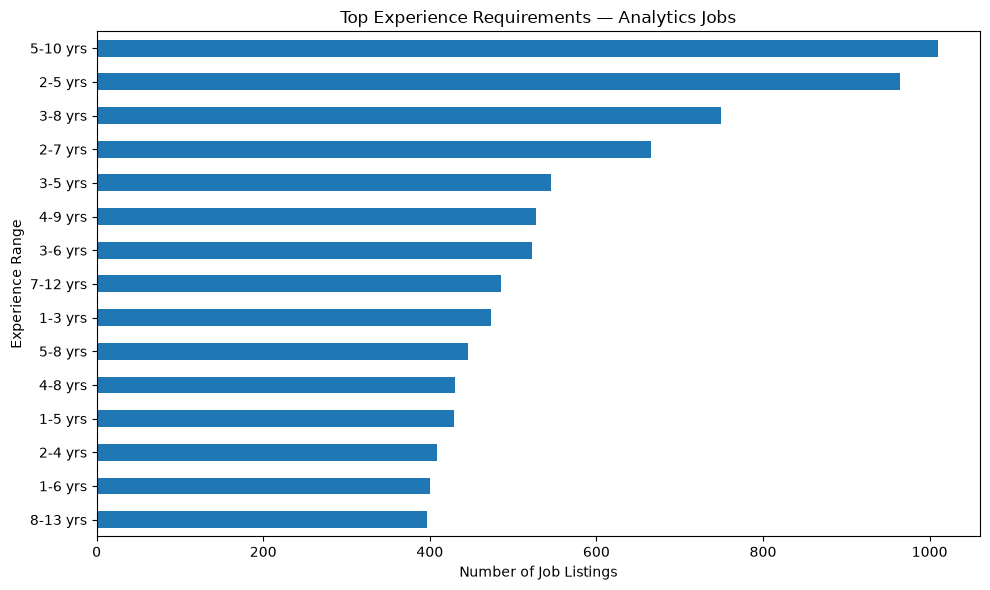

In [21]:
plt.figure(figsize=(10, 6))

experience_distribution.sort_values().plot(kind="barh")

plt.title("Top Experience Requirements — Analytics Jobs")
plt.xlabel("Number of Job Listings")
plt.ylabel("Experience Range")

plt.tight_layout()
plt.show()

### Most Common Analytics Job Roles

In [22]:
top_analytics_roles = (analytics_clean["job_desig"].value_counts().head(15))

display(top_analytics_roles)

job_desig
Business Analyst                                                        108
Data Scientist                                                           64
Data Analyst                                                             50
Digital Marketing Manager                                                45
Home Base Job/ Data Entry/online Work/part Time Work/freelancer work     45
Product Manager                                                          44
Digital Marketing Executive                                              36
Analyst                                                                  35
SEO Executive                                                            29
SEO Analyst                                                              26
Microsoft Advanced Analytics                                             24
Associate                                                                24
Application Developer                                                    22
Pr

### Visualization

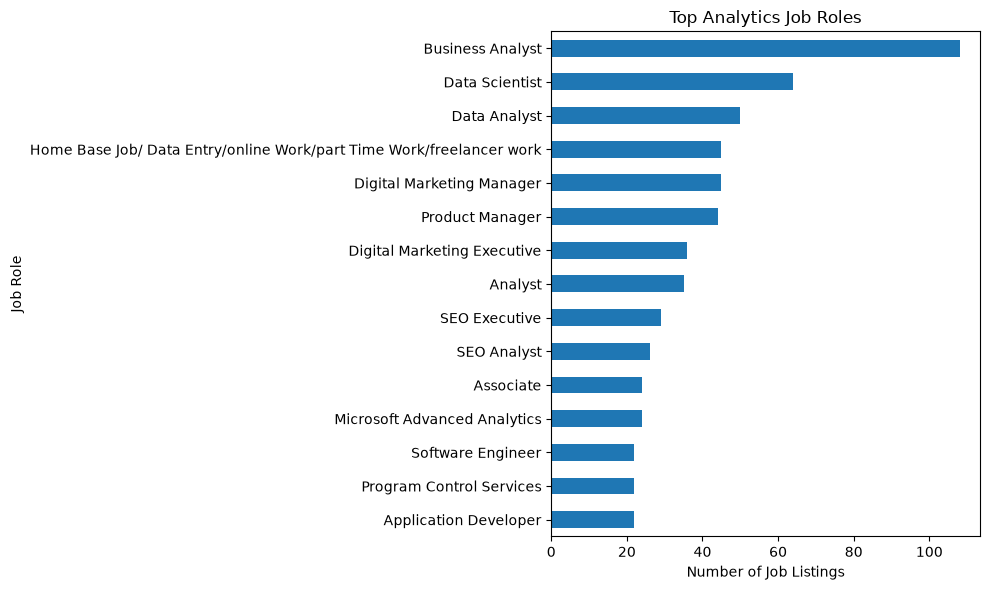

In [23]:
plt.figure(figsize=(10, 6))

top_analytics_roles.sort_values().plot(kind="barh")

plt.title("Top Analytics Job Roles")
plt.xlabel("Number of Job Listings")
plt.ylabel("Job Role")

plt.tight_layout()
plt.show()

### Geographic Distribution of Analytics Jobs

In [24]:
top_analytics_locations = (analytics_clean["location"].value_counts().head(15))

display(top_analytics_locations)

location
Bengaluru             3333
Mumbai                1992
Gurgaon               1313
Pune                   945
Hyderabad              878
Chennai                786
Delhi NCR              593
Noida                  403
Delhi NCR, Gurgaon     278
Delhi                  198
Gurgaon, Gurugram      195
Kolkata                159
Ahmedabad              150
Navi Mumbai            114
Kochi                   77
Name: count, dtype: int64[pyarrow]

### Visualization

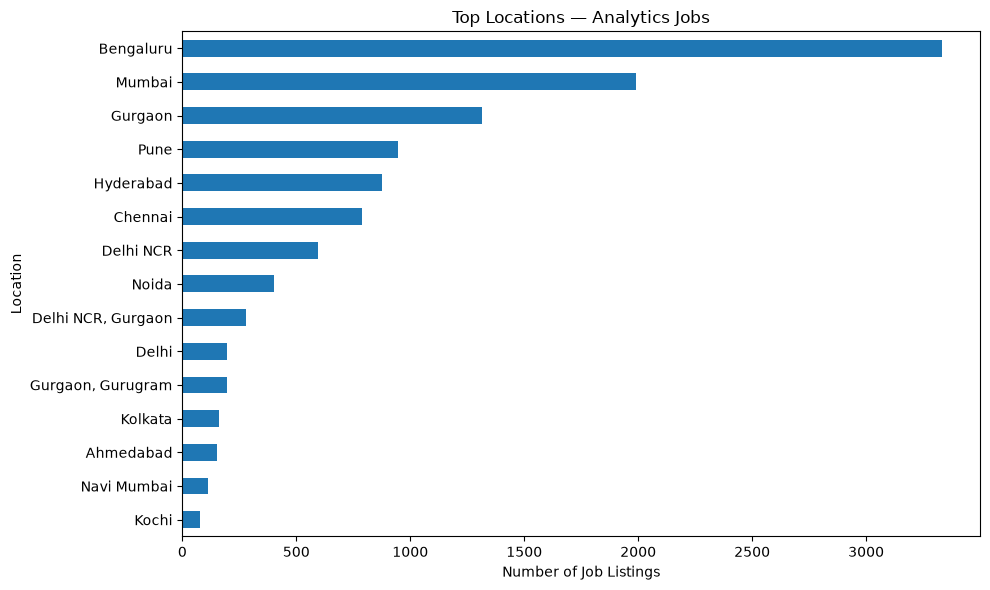

In [25]:
plt.figure(figsize=(10, 6))

top_analytics_locations.sort_values().plot(kind="barh")

plt.title("Top Locations — Analytics Jobs")
plt.xlabel("Number of Job Listings")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

### Salary Band Distribution — Analytics Jobs

In [26]:
analytics_salary_summary = (analytics_clean["salary_mid_lpa"].describe())

display(analytics_salary_summary)

count      15841.0
mean     12.270627
std       9.656391
min            1.5
25%            4.5
50%           12.5
75%           20.0
max           37.5
Name: salary_mid_lpa, dtype: Float64

### Visualization

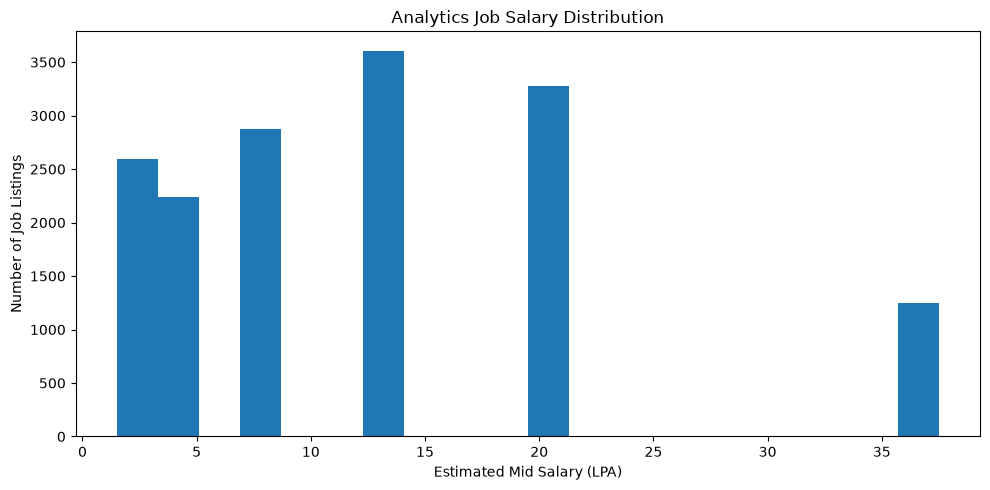

In [27]:
plt.figure(figsize=(10, 5))

plt.hist(analytics_clean["salary_mid_lpa"].dropna(),bins=20)

plt.title("Analytics Job Salary Distribution")
plt.xlabel("Estimated Mid Salary (LPA)")
plt.ylabel("Number of Job Listings")

plt.tight_layout()
plt.show()

### Experience vs Estimated Salary

In [28]:
analytics_salary_by_experience = (analytics_clean
    .groupby("min_experience_years")["salary_mid_lpa"]
    .agg(["count", "mean", "median"]).reset_index())

display(analytics_salary_by_experience.head(15))

,min_experience_years,count,mean,median
0,0,1344,2.784598,1.5
1,1,1796,5.518374,4.5
2,2,2579,7.703761,8.0
3,3,2203,10.29074,8.0
4,4,1527,12.352325,12.5
5,5,1843,14.150841,12.5
6,6,840,15.920238,12.5
7,7,856,18.005257,20.0
8,8,985,19.804061,20.0
9,9,255,20.680392,20.0


### Visualization

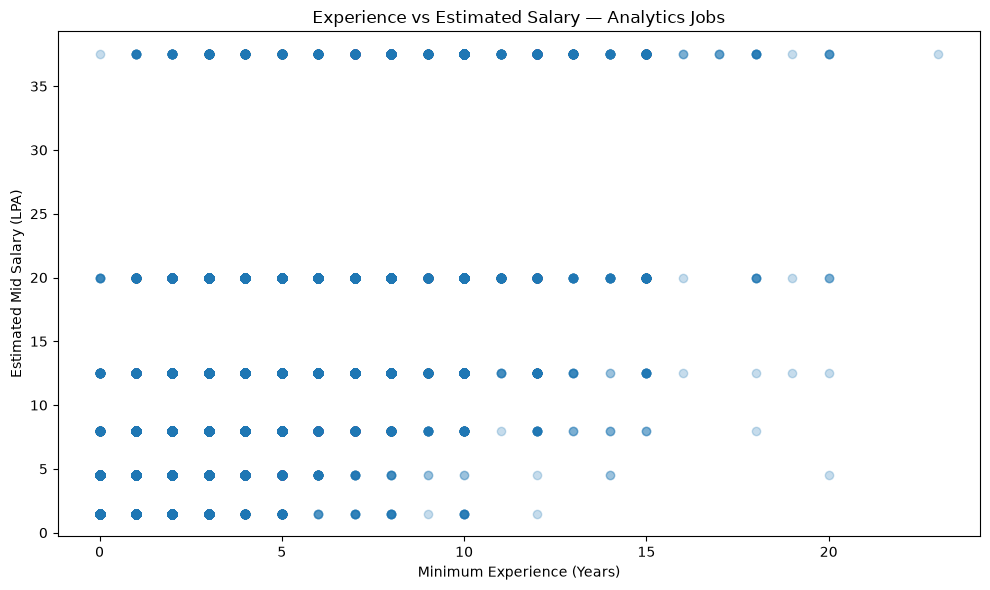

In [29]:
plt.figure(figsize=(10, 6))

plt.scatter(analytics_clean["min_experience_years"],
            analytics_clean["salary_mid_lpa"], alpha=0.25)

plt.title("Experience vs Estimated Salary — Analytics Jobs")
plt.xlabel("Minimum Experience (Years)")
plt.ylabel("Estimated Mid Salary (LPA)")

plt.tight_layout()
plt.show()

# Data Science Hiring Companies

### Data Science Job Market Analysis

In [30]:
top_ds_companies = (data_science_clean.groupby("company_name")["num_of_jobs"]
    .sum().sort_values(ascending=False).head(15))

display(top_ds_companies)

company_name
TCS                 9064
Accenture           5425
Cognizant           3813
Wipro               2566
IBM                 2480
Genpact             2147
Capgemini           1994
L&T Infotech        1873
Tech Mahindra       1830
HCL Technologies    1783
Deloitte            1714
Evalueserve         1698
Infosys             1686
Amazon              1279
DXC Technology      1076
Name: num_of_jobs, dtype: int64

### Visualization

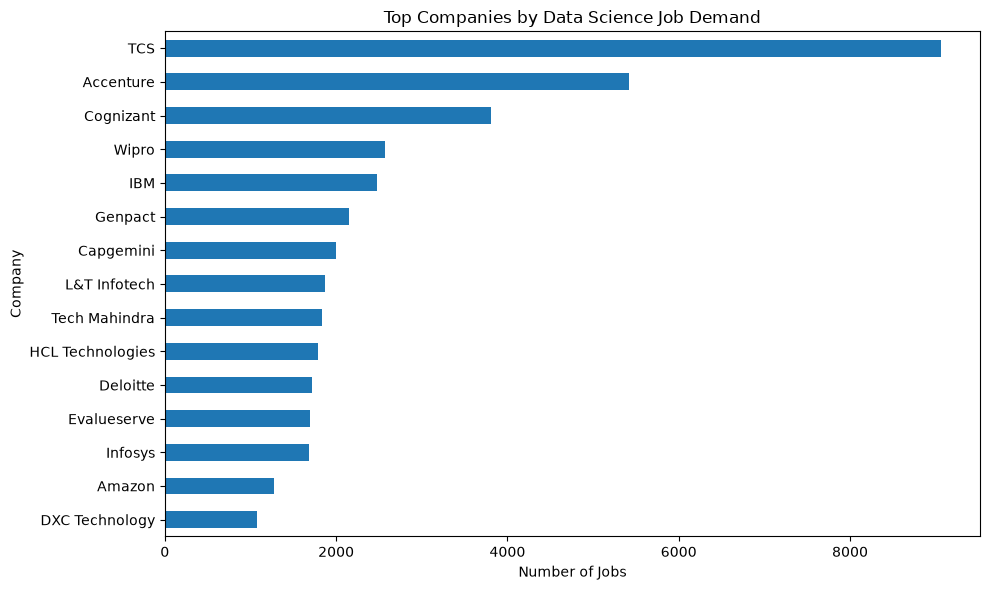

In [31]:
plt.figure(figsize=(10, 6))

top_ds_companies.sort_values().plot(kind="barh")

plt.title("Top Companies by Data Science Job Demand")
plt.xlabel("Number of Jobs")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

### Most Common Data Science Roles

In [32]:
top_ds_roles = (data_science_clean.groupby("job_title")["num_of_jobs"]
    .sum().sort_values(ascending=False).head(15))

display(top_ds_roles)

job_title
Business Analyst             32843
Data Analyst                 18095
Senior Business Analyst      14115
Data Scientist                9051
Data Engineer                 8044
Senior Data Analyst           3825
Senior Data Engineer          3411
Senior Data Scientist         2129
Machine Learning Engineer      964
Data Architect                 528
Name: num_of_jobs, dtype: int64

### Visualization

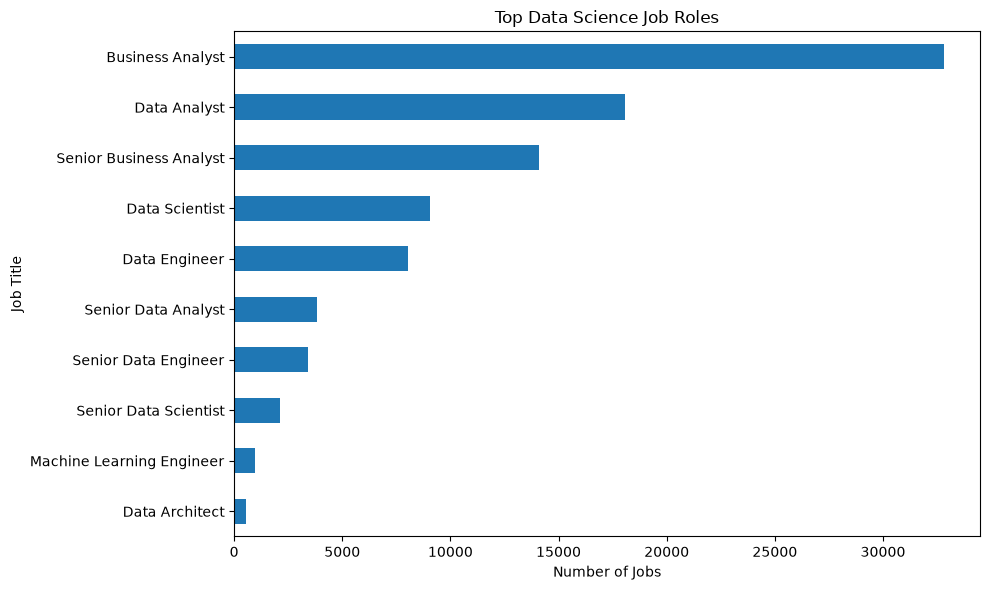

In [33]:
plt.figure(figsize=(10, 6))

top_ds_roles.sort_values().plot(kind="barh")

plt.title("Top Data Science Job Roles")
plt.xlabel("Number of Jobs")
plt.ylabel("Job Title")

plt.tight_layout()
plt.show()

### Salary Distribution in Data Science

In [34]:
ds_salary_summary = (data_science_clean["avg_salary_lpa"].describe())

display(ds_salary_summary)

count       1602.0
mean     13.234894
std       7.840744
min            1.4
25%            7.6
50%           11.9
75%         17.175
max           82.0
Name: avg_salary_lpa, dtype: Float64

### Visualization

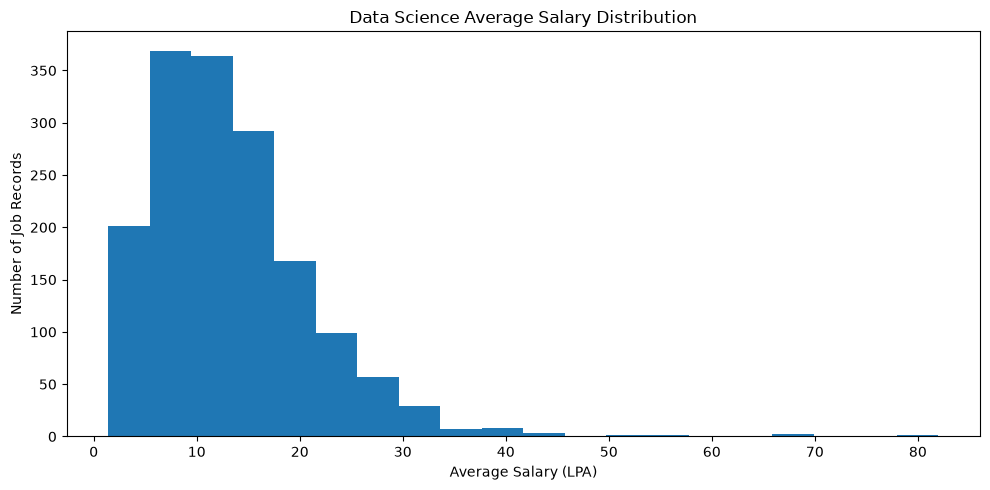

In [35]:
plt.figure(figsize=(10, 5))

plt.hist(data_science_clean["avg_salary_lpa"].dropna(),bins=20)

plt.title("Data Science Average Salary Distribution")
plt.xlabel("Average Salary (LPA)")
plt.ylabel("Number of Job Records")

plt.tight_layout()
plt.show()

### Experience vs Salary — Data Science

In [36]:
ds_salary_by_experience = (data_science_clean
    .groupby("min_experience")["avg_salary_lpa"]
    .agg(["count", "mean", "median"]).reset_index())

display(ds_salary_by_experience)

,min_experience,count,mean,median
0,0,170,7.321176,6.35
1,1,358,8.637989,7.8
2,2,356,11.972191,11.4
3,3,233,14.402575,12.8
4,4,191,15.902094,15.2
5,5,125,18.0536,16.4
6,6,55,21.376364,18.2
7,7,48,23.433333,21.95
8,8,27,24.477778,22.2
9,9,10,23.46,22.4


### Salary Range

In [37]:
data_science_clean["salary_range_lpa"] = (data_science_clean["max_salary_lpa"]
                                          - data_science_clean["min_salary_lpa"])

display(data_science_clean[["company_name", "job_title", "min_salary_lpa",
                            "max_salary_lpa", "salary_range_lpa"]]
    .sort_values("salary_range_lpa", ascending=False).head(15))

,company_name,job_title,min_salary_lpa,max_salary_lpa,salary_range_lpa
893,Innova Solutions,Senior Data Scientist,6.0,97.0,91.0
1592,Automatic Data Processing,Data Architect,14.0,102.0,88.0
919,Kyndryl,Senior Data Scientist,11.6,93.0,81.4
666,Google,Data Engineer,16.5,93.5,77.0
1442,Emirates Airlines,Senior Data Engineer,20.0,94.0,74.0
770,Microsoft Corporation,Senior Data Scientist,30.0,100.0,70.0
1585,Fidelity International,Data Architect,23.4,93.0,69.6
170,Apple,Data Scientist,8.2,74.5,66.3
1462,Uber,Senior Data Engineer,34.5,93.0,58.5
759,Amazon,Senior Data Scientist,26.0,75.0,49.0


### Highest Average Salary Companies

In [38]:
company_salary_analysis = (data_science_clean.groupby("company_name").agg(
    total_jobs=("num_of_jobs", "sum"),
    average_salary_lpa=("avg_salary_lpa", "mean"),
    maximum_salary_lpa=("max_salary_lpa", "max"))
    .sort_values("average_salary_lpa", ascending=False))

display(company_salary_analysis.head(15))

,total_jobs,average_salary_lpa,maximum_salary_lpa
company_name,,,
Emirates Airlines,5,68.3,94.0
Hitachi,3,40.0,50.0
Intuit,5,39.0,47.0
MSCI,4,38.4,42.0
Microsoft Corporation,127,37.866667,100.0
Automatic Data Processing,9,35.45,102.0
Innova Solutions,17,33.4,97.0
Fidelity International,44,33.25,93.0
Roche Diagnostics,4,33.1,43.0


### Important: avoid misleading salary conclusions

In [39]:
company_salary_filtered = (company_salary_analysis[company_salary_analysis["total_jobs"] >= 10]
    .sort_values("average_salary_lpa", ascending=False))

display(company_salary_filtered.head(15))

,total_jobs,average_salary_lpa,maximum_salary_lpa
company_name,,,
Microsoft Corporation,127,37.866667,100.0
Innova Solutions,17,33.4,97.0
Fidelity International,44,33.25,93.0
PepsiCo,11,31.55,49.0
Expedia,18,31.2,41.3
Koch Business Solutions,41,30.9,51.0
Uber,76,30.9,93.0
Go-Jek,15,30.5,44.0
Google,79,30.4,93.5


# Create a combined EDA summary

## EDA Summary

The exploratory analysis provides an initial view of:

- Demand by job role
- Hiring concentration by company
- Geographic concentration
- Experience requirements
- Salary distributions
- Experience-salary relationships
- Salary ranges

These findings will be used in the next stages for skill-demand analysis
and career intelligence.

## Skill Demand Analysis

This section identifies the most frequently mentioned skills in Analytics
job listings.

The `key_skills` field contains multiple skills within individual job
records. The skills are therefore extracted, standardized, and counted
across job listings.

The analysis will identify:

- Most frequently requested skills
- Skill demand by job market
- Skill combinations
- High-value skills based on available salary information

In [40]:
analytics_clean["key_skills"].head(10).tolist()

['Oracle SQL, PLSQL, PL, Oracle Forms, Oracle Reports, Oracle Workflow...',
 'Javascript, HTML, JQuery, Web Development, Play Framework, MVC, Rest...',
 'SNOW, Servicenow, Servicenow Developer',
 'QTP, Flex, LAN, Application support, Performance testing, Eclipse...',
 'HyperMesh, LS - DYNA, NASTRAN, Abaqus, Fatigue, Durability, NVH, FEA...',
 'Manager - Portfolio Analytics, Portfolio Analytics, Analytics...',
 'Project Management, Client Interfacing, Client Management, Data Analytics...',
 'Analysis, research, analyst, research analyst, research associate, research...',
 'SEO, Digital Marketing, Search Engine Marketing, Google AdWords, SEM...',
 'recovery, team handling, data analysis, team leader, collection...']

In [41]:
skill_series = (analytics_clean["key_skills"].fillna("Not Provided")
    .astype(str).str.lower().str.replace("&", " and ", regex=False))

skill_series.head()

0    oracle sql, plsql, pl, oracle forms, oracle re...
1    javascript, html, jquery, web development, pla...
2               snow, servicenow, servicenow developer
3    qtp, flex, lan, application support, performan...
4    hypermesh, ls - dyna, nastran, abaqus, fatigue...
Name: key_skills, dtype: str

### Split skills

In [42]:
skill_lists = (skill_series.str.split(","))

skill_lists.head()

0    [oracle sql,  plsql,  pl,  oracle forms,  orac...
1    [javascript,  html,  jquery,  web development,...
2           [snow,  servicenow,  servicenow developer]
3    [qtp,  flex,  lan,  application support,  perf...
4    [hypermesh,  ls - dyna,  nastran,  abaqus,  fa...
Name: key_skills, dtype: object

In [43]:
skills_long = skill_lists.explode()

skills_long = (skills_long.str.strip())

skills_long.head(20)

0              oracle sql
0                   plsql
0                      pl
0            oracle forms
0          oracle reports
0      oracle workflow...
1              javascript
1                    html
1                  jquery
1         web development
1          play framework
1                     mvc
1                 rest...
2                    snow
2              servicenow
2    servicenow developer
3                     qtp
3                    flex
3                     lan
3     application support
Name: key_skills, dtype: str

### Remove unusable values

In [44]:
skills_long = skills_long[skills_long.notna() 
    & (skills_long != "") & (skills_long != "not provided")]

skills_long = skills_long.reset_index(drop=True)

print("Total skill mentions:", len(skills_long))
print("Unique skill labels:", skills_long.nunique())

Total skill mentions: 79880
Unique skill labels: 10658


### Top skills

In [45]:
top_skills = (skills_long.value_counts().head(30))

display(top_skills)

key_skills
...                     946
sql                     915
analytics               904
python                  840
finance                 756
java                    726
r                       655
sas                     636
business analysis       633
machine learning        629
data analysis           618
digital marketing       566
javascript              535
project management      505
seo                     495
data analytics          412
sales                   404
excel                   393
accounting              376
outsourcing             360
marketing               326
html                    305
hadoop                  300
spark                   284
business process        280
data science            271
big data                263
business development    253
auditing                247
financial analysis      245
Name: count, dtype: int64

### Visualize top skills

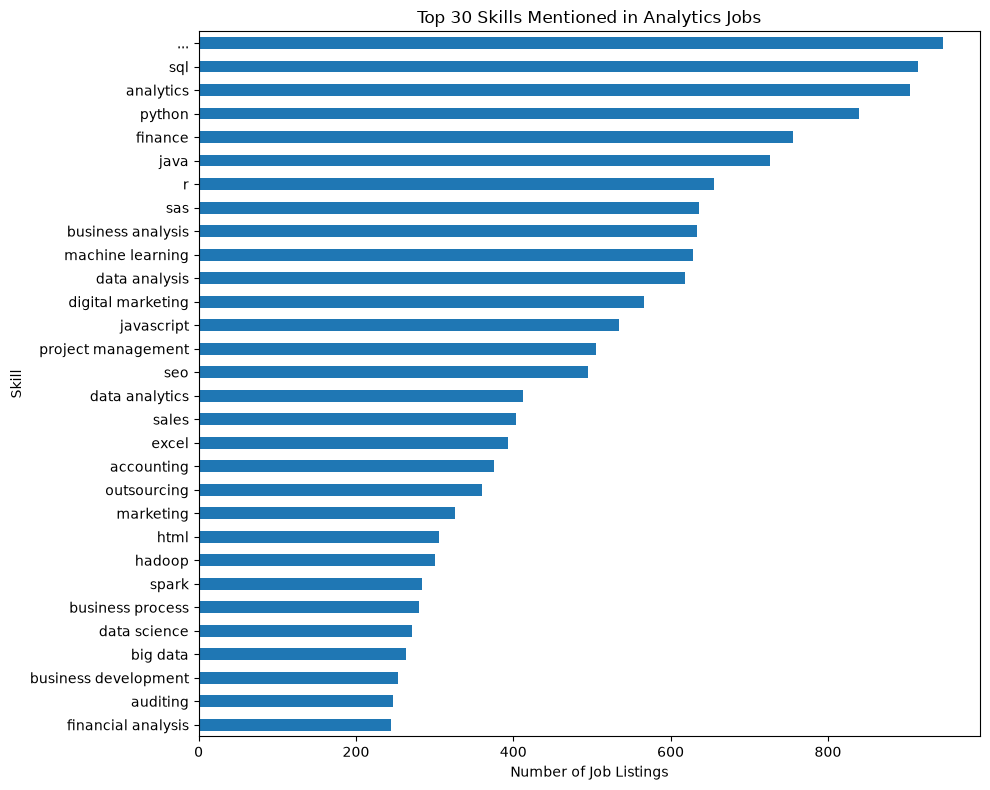

In [46]:
plt.figure(figsize=(10, 8))

top_skills.sort_values().plot(kind="barh")

plt.title("Top 30 Skills Mentioned in Analytics Jobs")
plt.xlabel("Number of Job Listings")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

### Skill Demand Interpretation

Skill frequency provides an indication of how often a skill appears in
the available job listings.

However, frequency alone does not establish that a skill causes higher
salary or better career outcomes. Salary and skill relationships will
therefore be analyzed separately.

In [47]:
total_jobs = len(analytics_clean)

skill_demand = (top_skills.to_frame("job_listing_count"))

skill_demand["job_listing_share_%"] = (skill_demand["job_listing_count"] / total_jobs* 100)

skill_demand["job_listing_share_%"] = (skill_demand["job_listing_share_%"].round(2))

display(skill_demand)

,job_listing_count,job_listing_share_%
key_skills,,
...,946,5.97
sql,915,5.78
analytics,904,5.71
python,840,5.30
finance,756,4.77
java,726,4.58
r,655,4.13
sas,636,4.01
business analysis,633,4.00


## Skill + Salary Analysis
### Relationship between each job and its skills

In [48]:
analytics_skill_data = analytics_clean[["key_skills", "salary_mid_lpa", 
                                        "job_desig", "location", 
                                        "min_experience_years"]].copy()

In [49]:
analytics_skill_data["skill"] = (analytics_skill_data["key_skills"]
    .fillna("Not Provided").astype(str).str.lower().str.split(","))

analytics_skill_data = (analytics_skill_data.explode("skill"))

analytics_skill_data["skill"] = (analytics_skill_data["skill"].str.strip())

analytics_skill_data = analytics_skill_data[(analytics_skill_data["skill"] != "")
    & (analytics_skill_data["skill"] != "not provided")]

analytics_skill_data.head()

,key_skills,salary_mid_lpa,job_desig,location,min_experience_years,skill
0,"Oracle SQL, PLSQL, PL, Oracle Forms, Oracle Re...",8.0,Oracle EBS Technical Consultant,"Bengaluru, Chennai",6,oracle sql
0,"Oracle SQL, PLSQL, PL, Oracle Forms, Oracle Re...",8.0,Oracle EBS Technical Consultant,"Bengaluru, Chennai",6,plsql
0,"Oracle SQL, PLSQL, PL, Oracle Forms, Oracle Re...",8.0,Oracle EBS Technical Consultant,"Bengaluru, Chennai",6,pl
0,"Oracle SQL, PLSQL, PL, Oracle Forms, Oracle Re...",8.0,Oracle EBS Technical Consultant,"Bengaluru, Chennai",6,oracle forms
0,"Oracle SQL, PLSQL, PL, Oracle Forms, Oracle Re...",8.0,Oracle EBS Technical Consultant,"Bengaluru, Chennai",6,oracle reports


In [50]:
skill_salary_analysis = (analytics_skill_data.groupby("skill").agg(
        job_count=("salary_mid_lpa", "count"),
        average_salary_lpa=("salary_mid_lpa", "mean"),
        median_salary_lpa=("salary_mid_lpa", "median")))

skill_salary_filtered = (skill_salary_analysis[
    skill_salary_analysis["job_count"] >= 10].sort_values(
        "average_salary_lpa", ascending=False))

display(skill_salary_filtered.head(20))

,job_count,average_salary_lpa,median_salary_lpa
skill,,,
analytics head,24,32.3125,37.5
portfolio risk reporting...,10,32.25,37.5
fraud analytics,17,30.823529,37.5
technology consulting,10,30.5,37.5
credit risk analytics,13,29.692308,37.5
customer management,19,29.236842,37.5
anova,29,28.413793,37.5
people management skills,23,27.891304,37.5
correlation,21,27.428571,37.5


### Top skills by salary

In [51]:
top_salary_skills = (skill_salary_filtered.head(15))

display(top_salary_skills)

,job_count,average_salary_lpa,median_salary_lpa
skill,,,
analytics head,24,32.3125,37.5
portfolio risk reporting...,10,32.25,37.5
fraud analytics,17,30.823529,37.5
technology consulting,10,30.5,37.5
credit risk analytics,13,29.692308,37.5
customer management,19,29.236842,37.5
anova,29,28.413793,37.5
people management skills,23,27.891304,37.5
correlation,21,27.428571,37.5


### Visualization

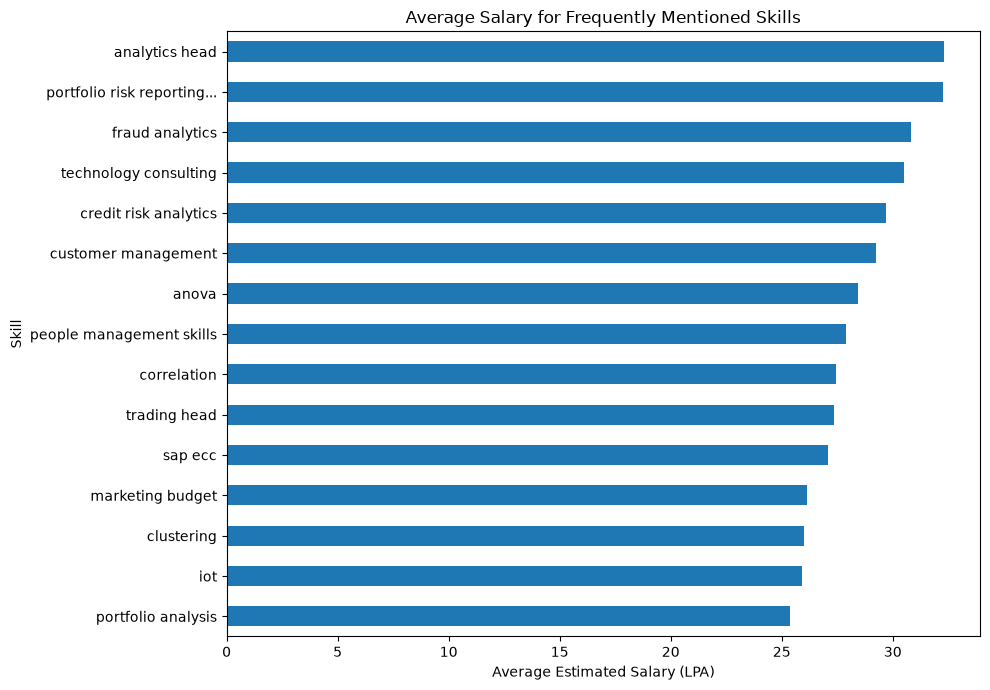

In [52]:
plt.figure(figsize=(10, 7))

top_salary_skills["average_salary_lpa"].sort_values().plot(kind="barh")

plt.title("Average Salary for Frequently Mentioned Skills")

plt.xlabel("Average Estimated Salary (LPA)")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

### Top skills by job demand + salary

In [53]:
skill_career_summary = (skill_salary_analysis.reset_index())

skill_career_summary = (skill_career_summary[skill_career_summary["job_count"] >= 10]
    .sort_values("job_count",ascending=False))

skill_career_summary["demand_share_%"] = (skill_career_summary["job_count"] / total_jobs* 100)

skill_career_summary["demand_share_%"] = (skill_career_summary["demand_share_%"].round(2))

display(skill_career_summary.head(20))

,skill,job_count,average_salary_lpa,median_salary_lpa,demand_share_%
41,...,946,12.109408,12.5,5.97
9208,sql,915,12.697814,12.5,5.78
447,analytics,904,14.199668,12.5,5.71
7641,python,840,14.006548,12.5,5.3
3618,finance,756,13.581349,12.5,4.77
5038,java,726,15.475895,12.5,4.58
7837,r,655,17.747328,20.0,4.13
8475,sas,636,17.139151,12.5,4.01
1262,business analysis,633,12.483412,12.5,4.0
5526,machine learning,629,16.594595,12.5,3.97


In [54]:
### Create a descriptive score combining normalized demand and salarym

In [55]:
career_skill = skill_career_summary.copy()

career_skill["demand_score"] = (career_skill["job_count"]
                                / career_skill["job_count"].max())

career_skill["salary_score"] = (career_skill["average_salary_lpa"]
                                / career_skill["average_salary_lpa"].max())

career_skill["career_signal_score"] = (0.7 * career_skill["demand_score"]
                                       + 0.3 * career_skill["salary_score"])

career_skill = (career_skill.sort_values("career_signal_score",ascending=False))

display(career_skill[["skill","job_count","demand_share_%",
            "average_salary_lpa","career_signal_score"]].head(20))

,skill,job_count,demand_share_%,average_salary_lpa,career_signal_score
41,...,946,5.97,12.109408,0.812428
447,analytics,904,5.71,14.199668,0.800756
9208,sql,915,5.78,12.697814,0.794952
7641,python,840,5.3,14.006548,0.751606
3618,finance,756,4.77,13.581349,0.685502
5038,java,726,4.58,15.475895,0.680893
7837,r,655,4.13,17.747328,0.649444
8475,sas,636,4.01,17.139151,0.629739
5526,machine learning,629,3.97,16.594595,0.619503
1262,business analysis,633,4.0,12.483412,0.584293


## Career Intelligence Interpretation

The skill analysis combines two descriptive signals:

1. Demand — how frequently a skill appears in job listings.
2. Salary — the average estimated salary associated with listings
   mentioning the skill.

A combined career signal is used only for exploratory ranking.

It should not be interpreted as proof that a particular skill directly
causes higher salary or employment outcomes.

## Skill & Role Intelligence

This section connects individual skills with job roles.

The objective is to understand:

- Which skills are common within specific roles
- Which roles have the broadest skill requirements
- Which skills are associated with Data Science and Analytics roles
- How skill requirements differ across career paths

The analysis is descriptive and reflects the available job listings.

### Create role-skill dataset

In [56]:
role_skill_data = analytics_clean[["job_desig", "key_skills", 
                                   "salary_mid_lpa", "min_experience_years"]].copy()

role_skill_data["skill"] = (role_skill_data["key_skills"]
    .fillna("Not Provided").astype(str).str.lower().str.split(","))

role_skill_data = role_skill_data.explode("skill")

role_skill_data["skill"] = (role_skill_data["skill"].str.strip())

role_skill_data = role_skill_data[(role_skill_data["skill"] != "")
    & (role_skill_data["skill"] != "not provided")]

role_skill_data.head()

,job_desig,key_skills,salary_mid_lpa,min_experience_years,skill
0,Oracle EBS Technical Consultant,"Oracle SQL, PLSQL, PL, Oracle Forms, Oracle Re...",8.0,6,oracle sql
0,Oracle EBS Technical Consultant,"Oracle SQL, PLSQL, PL, Oracle Forms, Oracle Re...",8.0,6,plsql
0,Oracle EBS Technical Consultant,"Oracle SQL, PLSQL, PL, Oracle Forms, Oracle Re...",8.0,6,pl
0,Oracle EBS Technical Consultant,"Oracle SQL, PLSQL, PL, Oracle Forms, Oracle Re...",8.0,6,oracle forms
0,Oracle EBS Technical Consultant,"Oracle SQL, PLSQL, PL, Oracle Forms, Oracle Re...",8.0,6,oracle reports


### Skills Associated with Data Scientist Roles

In [57]:
data_scientist_skills = (role_skill_data[role_skill_data["job_desig"]
    .str.contains("data scientist", case=False, na=False)]["skill"]
    .value_counts().head(20))

display(data_scientist_skills)

skill
machine learning               180
python                         165
r                              129
data science                    96
deep learning                   71
data scientist                  66
sql                             57
java                            46
nlp                             42
data mining                     39
hadoop                          32
sas                             31
analytics                       31
spark                           30
data analysis                   30
scala                           29
predictive analytics            28
neural networks                 27
natural language processing     26
text mining                     23
Name: count, dtype: int64

### Visualize

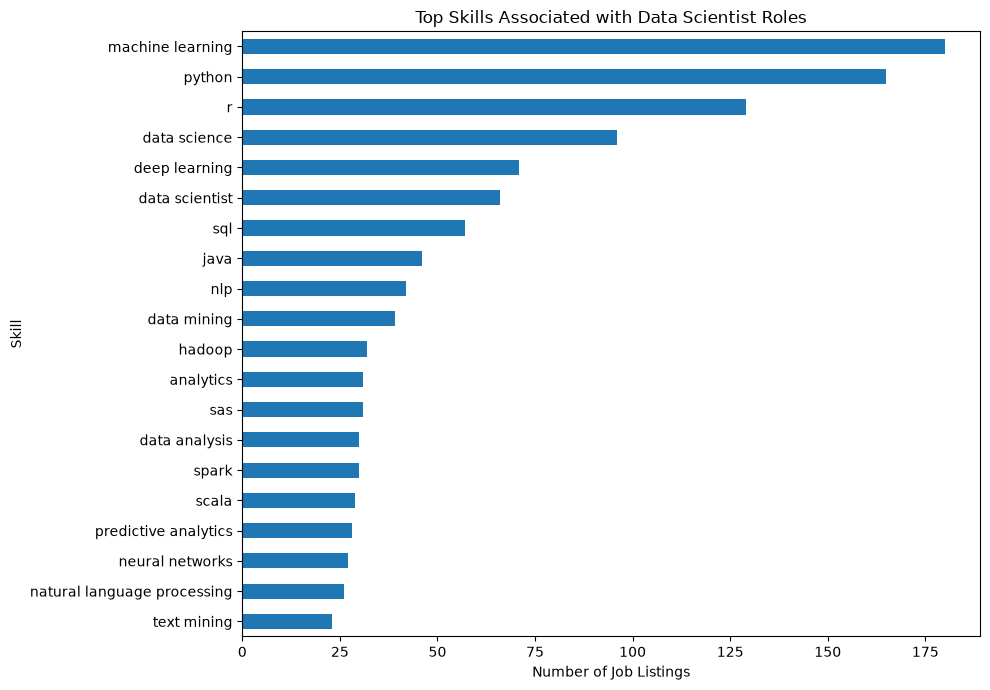

In [58]:
plt.figure(figsize=(10, 7))

data_scientist_skills.sort_values().plot(kind="barh")

plt.title("Top Skills Associated with Data Scientist Roles")
plt.xlabel("Number of Job Listings")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

### Skills Associated with Data Analyst Roles

In [59]:
data_analyst_skills = (role_skill_data[role_skill_data["job_desig"]
    .str.contains("data analyst", case=False, na=False)]["skill"]
    .value_counts().head(20))

display(data_analyst_skills)

skill
data analysis            147
excel                     51
sql                       49
python                    41
r                         39
data analyst              35
data analytics            35
data mining               31
machine learning          28
sas                       22
advanced excel            17
data analysis...          16
mysql                     16
tableau                   15
data visualization        14
macros                    14
analytics                 14
sql queries               11
business intelligence     10
mis                       10
Name: count, dtype: int64

### Visualization

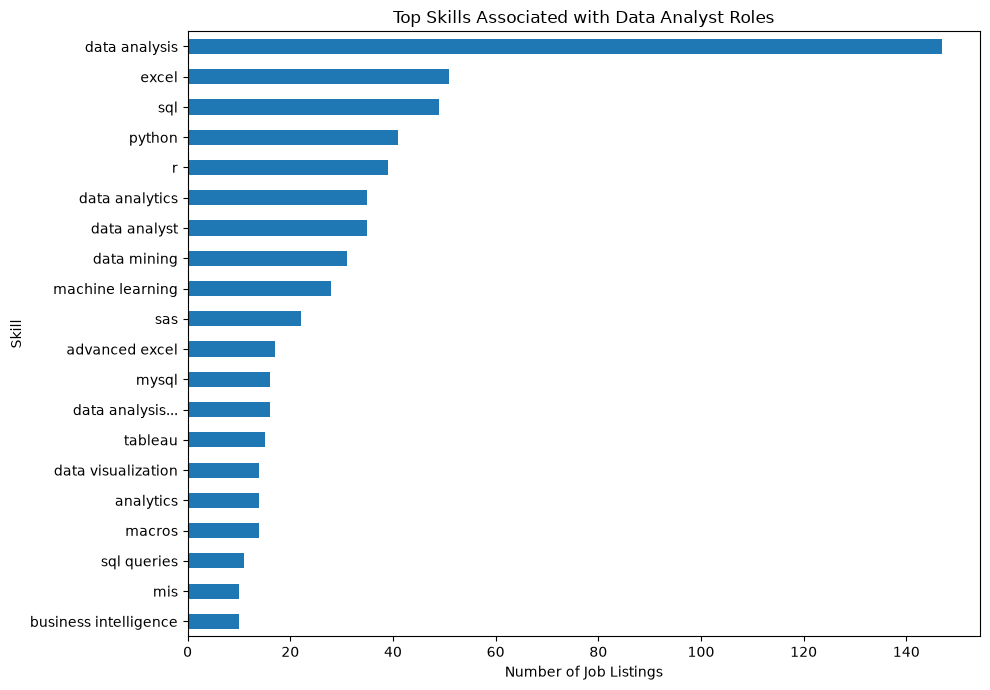

In [60]:
plt.figure(figsize=(10, 7))

data_analyst_skills.sort_values().plot(kind="barh")

plt.title("Top Skills Associated with Data Analyst Roles")
plt.xlabel("Number of Job Listings")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

### Business Analyst skills


In [61]:
business_analyst_skills = (role_skill_data[role_skill_data["job_desig"]
    .str.contains("business analyst", case=False, na=False)]["skill"]
    .value_counts().head(20))

display(business_analyst_skills)

skill
business analysis        433
business analyst         114
sql                       61
...                       54
business analysis...      49
requirement gathering     39
analytics                 38
data analytics            37
uat                       36
user stories              35
use cases                 35
sas                       34
data analysis             33
project management        32
excel                     32
python                    27
r                         26
finance                   25
brd                       24
business analytics        23
Name: count, dtype: int64

### Visualization

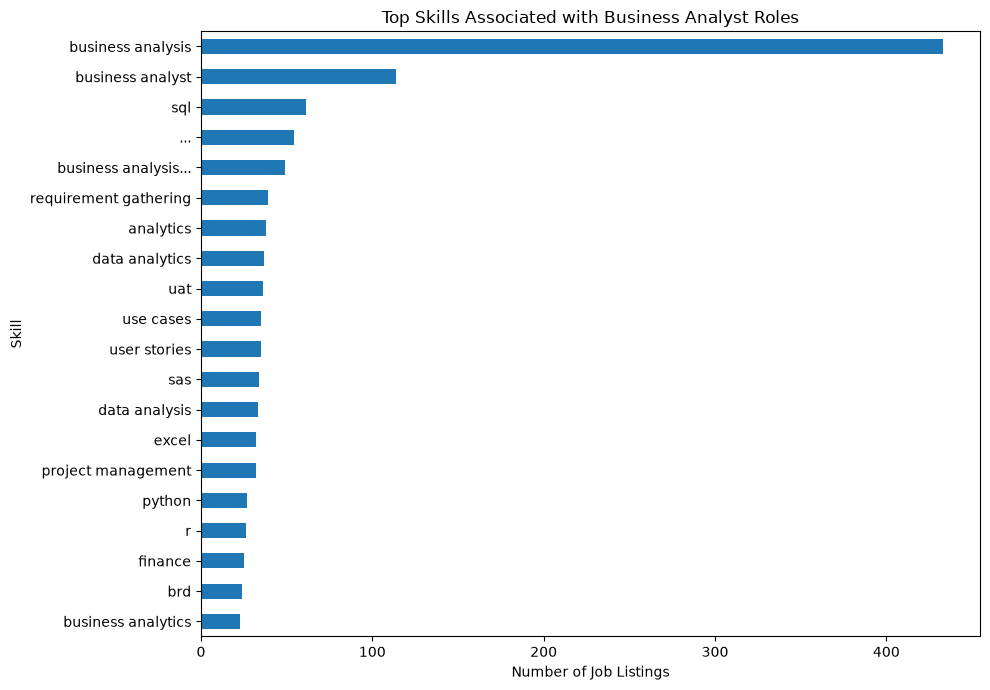

In [62]:
plt.figure(figsize=(10, 7))

business_analyst_skills.sort_values().plot(kind="barh")

plt.title("Top Skills Associated with Business Analyst Roles")
plt.xlabel("Number of Job Listings")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

### Create a single comparison table

In [63]:
role_skill_comparison = pd.DataFrame({
    "Data Scientist": data_scientist_skills.head(10),
    "Data Analyst": data_analyst_skills.head(10),
    "Business Analyst": business_analyst_skills.head(10)})

display(role_skill_comparison)

,Data Scientist,Data Analyst,Business Analyst
skill,,,
...,NaN,NaN,54.0
analytics,NaN,NaN,38.0
business analysis,NaN,NaN,433.0
business analysis...,NaN,NaN,49.0
business analyst,NaN,NaN,114.0
data analysis,NaN,147.0,NaN
data analyst,NaN,35.0,NaN
data analytics,NaN,35.0,37.0
data mining,39.0,31.0,NaN


### Identify role-specific skills

In [64]:
def skill_share_for_role(role_keyword):

    role_data = role_skill_data[role_skill_data["job_desig"]
        .str.contains(role_keyword,case=False,na=False)].copy()

    total_role_listings = (role_data["job_desig"].count())

    skill_counts = role_data["skill"].value_counts()

    return (skill_counts / total_role_listings* 100)

In [65]:
ds_skill_share = skill_share_for_role("data scientist")

da_skill_share = skill_share_for_role("data analyst")

ba_skill_share = skill_share_for_role("business analyst")

### Create role profiles

In [66]:
role_profiles = pd.DataFrame({
    "Data Scientist": ds_skill_share.head(15),
    "Data Analyst": da_skill_share.head(15),
    "Business Analyst": ba_skill_share.head(15)})

display(role_profiles.round(2))

,Data Scientist,Data Analyst,Business Analyst
skill,,,
...,NaN,NaN,1.50
advanced excel,NaN,1.18,NaN
analytics,1.45,NaN,1.05
business analysis,NaN,NaN,11.99
business analysis...,NaN,NaN,1.36
business analyst,NaN,NaN,3.16
data analysis,1.40,10.20,0.91
data analysis...,NaN,1.11,NaN
data analyst,NaN,2.43,NaN


## Career Path Skill Comparison

The role profiles provide a descriptive comparison of skill requirements
across Data Scientist, Data Analyst, and Business Analyst positions.

This comparison can help identify overlapping skills as well as skills
that appear more frequently within particular career paths.

In [67]:
career_path_summary = pd.DataFrame({"Career Path": ["Data Scientist",
                                                    "Data Analyst",
                                                    "Business Analyst"],
                                    "Top Skills": [
                                        ", ".join(data_scientist_skills.head(8).index),
                                        ", ".join(data_analyst_skills.head(8).index),
                                        ", ".join(business_analyst_skills.head(8).index)]})

display(career_path_summary)

,Career Path,Top Skills
0,Data Scientist,"machine learning, python, r, data science, dee..."
1,Data Analyst,"data analysis, excel, sql, python, r, data ana..."
2,Business Analyst,"business analysis, business analyst, sql, ...,..."


### Common skills

In [68]:
ds_top = set(data_scientist_skills.head(15).index)
da_top = set(data_analyst_skills.head(15).index)
ba_top = set(business_analyst_skills.head(15).index)

common_all_three = (ds_top & da_top & ba_top)

print("Skills common across all three career paths:")
print(sorted(common_all_three))

Skills common across all three career paths:
['data analysis', 'sas', 'sql']


### Transferable skills

In [69]:
transferable_skills = ((ds_top & da_top) | (ds_top & ba_top) | (da_top & ba_top))

print("Transferable skills appearing across multiple career paths:")
print(sorted(transferable_skills))

Transferable skills appearing across multiple career paths:
['analytics', 'data analysis', 'data analytics', 'data mining', 'excel', 'machine learning', 'python', 'r', 'sas', 'sql']


## Career Intelligence Insight

The skill-role analysis helps distinguish between:

- Core skills common across multiple career paths
- Skills more strongly associated with Data Science
- Skills more strongly associated with Data Analytics
- Skills more strongly associated with Business Analytics

These results are descriptive observations from the available job
listings and should not be interpreted as guarantees of employment,
salary, or career success.

## Job Demand & Salary Intelligence

This section combines job demand, salary, and experience information to
create a broader view of the job market.

The analysis focuses on descriptive market signals rather than predicting
individual employment or compensation outcomes.

### Role demand analysis

In [70]:
role_demand = (analytics_clean.groupby("job_desig").agg(
    job_listings=("job_desig", "size"),
    average_salary_lpa=("salary_mid_lpa", "mean"),
    median_salary_lpa=("salary_mid_lpa", "median"),
    average_min_experience=("min_experience_years","mean"))
    .sort_values("job_listings",ascending=False))

display(role_demand.head(20))

,job_listings,average_salary_lpa,median_salary_lpa,average_min_experience
job_desig,,,,
Business Analyst,108,9.111111,8.0,3.287037
Data Scientist,64,13.3125,12.5,3.609375
Data Analyst,50,8.38,8.0,3.18
Digital Marketing Manager,45,8.377778,8.0,3.866667
Home Base Job/ Data Entry/online Work/part Time Work/freelancer work,45,3.033333,4.5,0.044444
Product Manager,44,13.909091,12.5,3.954545
Digital Marketing Executive,36,3.388889,3.0,1.416667
Analyst,35,8.1,8.0,3.485714
SEO Executive,29,3.948276,4.5,1.206897


### Filter small samples

In [71]:
role_demand_filtered = (role_demand[role_demand["job_listings"] >= 10].copy())

display(role_demand_filtered.head(20))

,job_listings,average_salary_lpa,median_salary_lpa,average_min_experience
job_desig,,,,
Business Analyst,108,9.111111,8.0,3.287037
Data Scientist,64,13.3125,12.5,3.609375
Data Analyst,50,8.38,8.0,3.18
Digital Marketing Manager,45,8.377778,8.0,3.866667
Home Base Job/ Data Entry/online Work/part Time Work/freelancer work,45,3.033333,4.5,0.044444
Product Manager,44,13.909091,12.5,3.954545
Digital Marketing Executive,36,3.388889,3.0,1.416667
Analyst,35,8.1,8.0,3.485714
SEO Executive,29,3.948276,4.5,1.206897


### Top roles by demand

In [72]:
top_roles_by_demand = (role_demand_filtered.sort_values(
    "job_listings", ascending=False).head(15))

display(top_roles_by_demand)

,job_listings,average_salary_lpa,median_salary_lpa,average_min_experience
job_desig,,,,
Business Analyst,108,9.111111,8.0,3.287037
Data Scientist,64,13.3125,12.5,3.609375
Data Analyst,50,8.38,8.0,3.18
Digital Marketing Manager,45,8.377778,8.0,3.866667
Home Base Job/ Data Entry/online Work/part Time Work/freelancer work,45,3.033333,4.5,0.044444
Product Manager,44,13.909091,12.5,3.954545
Digital Marketing Executive,36,3.388889,3.0,1.416667
Analyst,35,8.1,8.0,3.485714
SEO Executive,29,3.948276,4.5,1.206897


### Visualization

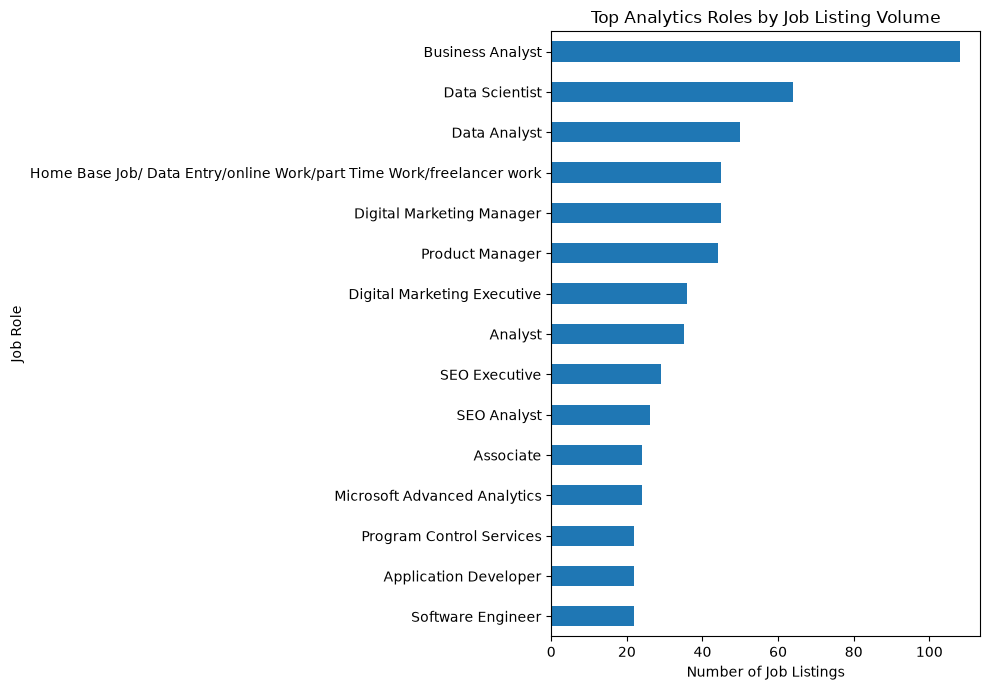

In [73]:
plt.figure(figsize=(10, 7))

top_roles_by_demand["job_listings"].sort_values().plot(kind="barh")

plt.title("Top Analytics Roles by Job Listing Volume")
plt.xlabel("Number of Job Listings")
plt.ylabel("Job Role")

plt.tight_layout()
plt.show()

### Highest-paying roles with sufficient demand

In [74]:
top_roles_by_salary = (role_demand_filtered.sort_values(
    "average_salary_lpa",ascending=False).head(15))

display(top_roles_by_salary)

,job_listings,average_salary_lpa,median_salary_lpa,average_min_experience
job_desig,,,,
Associate Vice President - Fraud Analytics - SAS - Bank,13,37.5,37.5,10.230769
Associate Vice President - Analytics - SAS - Bank,13,36.153846,37.5,9.769231
Senior Manager - Retail Analytics - Analytics Firm,13,34.807692,37.5,9.769231
Trading Head - Market Making/high Frequency Trading - Iit/nit/bits,11,28.454545,37.5,5.545455
Assistant Vice President - Insurance Analytics,10,27.0,20.0,8.8
Technical Manager,11,26.363636,20.0,8.636364
Quantitative Analyst - HFT,10,23.75,20.0,5.1
Financial Controller,10,21.0,20.0,5.3
Manager - Supply Chain Analytics - Consulting Firm,10,18.8,20.0,8.0


### Visualization

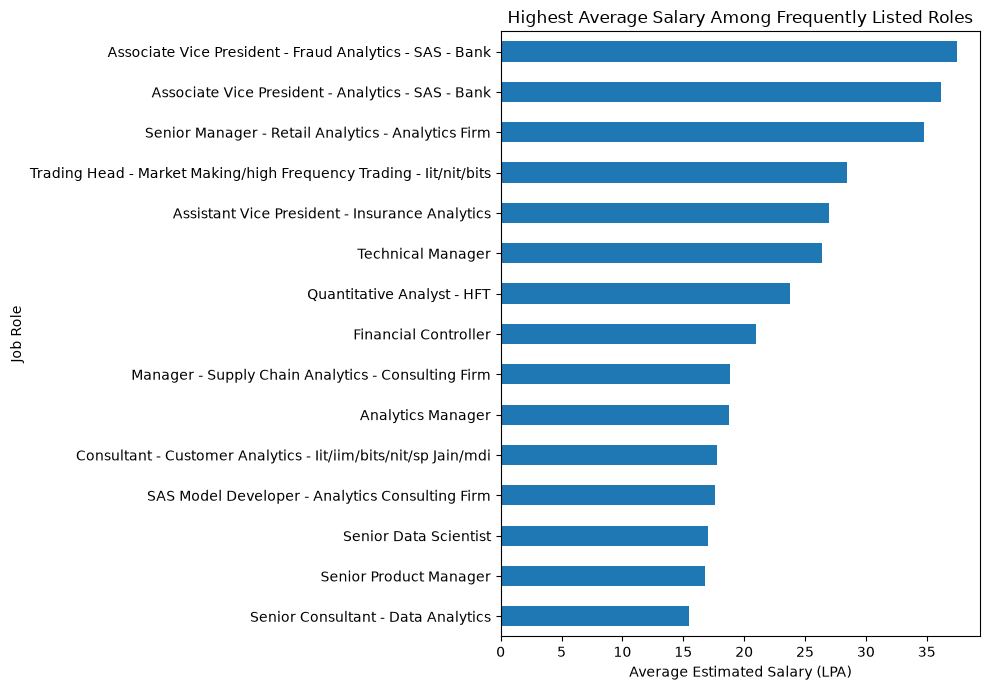

In [75]:
plt.figure(figsize=(10, 7))

top_roles_by_salary["average_salary_lpa"].sort_values().plot(kind="barh")

plt.title("Highest Average Salary Among Frequently Listed Roles")
plt.xlabel("Average Estimated Salary (LPA)")
plt.ylabel("Job Role")

plt.tight_layout()
plt.show()

## Demand vs Salary

This visualization compares the number of job listings with estimated
salary levels.

It helps distinguish high-demand roles from high-salary roles.

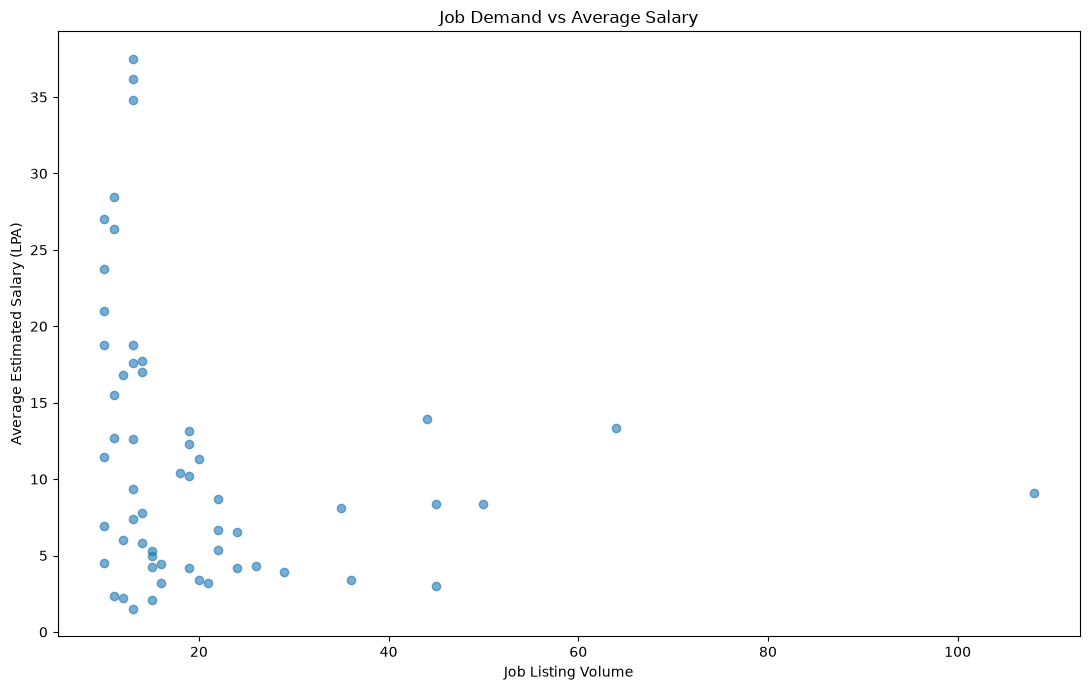

In [76]:
plt.figure(figsize=(11, 7))

plt.scatter(role_demand_filtered["job_listings"],
    role_demand_filtered["average_salary_lpa"],alpha=0.6)

plt.xlabel("Job Listing Volume")
plt.ylabel("Average Estimated Salary (LPA)")
plt.title("Job Demand vs Average Salary")

plt.tight_layout()
plt.show()

### Experience vs salary by role

In [77]:
role_experience_salary = (analytics_clean.groupby("job_desig")
    .agg(job_listings=("job_desig", "size"), average_experience=(
        "min_experience_years", "mean"), average_salary=(
        "salary_mid_lpa", "mean")))

role_experience_salary_filtered = (role_experience_salary[
    role_experience_salary["job_listings"] >= 10])

display(role_experience_salary_filtered
    .sort_values("average_salary", ascending=False).head(20))

,job_listings,average_experience,average_salary
job_desig,,,
Associate Vice President - Fraud Analytics - SAS - Bank,13,10.230769,37.5
Associate Vice President - Analytics - SAS - Bank,13,9.769231,36.153846
Senior Manager - Retail Analytics - Analytics Firm,13,9.769231,34.807692
Trading Head - Market Making/high Frequency Trading - Iit/nit/bits,11,5.545455,28.454545
Assistant Vice President - Insurance Analytics,10,8.8,27.0
Technical Manager,11,8.636364,26.363636
Quantitative Analyst - HFT,10,5.1,23.75
Financial Controller,10,5.3,21.0
Manager - Supply Chain Analytics - Consulting Firm,10,8.0,18.8


### Company demand + salary

In [78]:
company_intelligence = (data_science_clean.groupby("company_name")
    .agg(total_job_demand=("num_of_jobs","sum"),
         average_salary_lpa=("avg_salary_lpa", "mean"),
         maximum_salary_lpa=("max_salary_lpa", "max"),
         minimum_salary_lpa=("min_salary_lpa", "min")))

company_intelligence = (company_intelligence[company_intelligence["total_job_demand"] >= 10].copy())

display(company_intelligence.sort_values("total_job_demand",ascending=False).head(20))

,total_job_demand,average_salary_lpa,maximum_salary_lpa,minimum_salary_lpa
company_name,,,,
TCS,9064,9.46,30.0,2.4
Accenture,5425,12.19,33.0,2.3
Cognizant,3813,11.21,25.5,2.9
Wipro,2566,10.49,30.0,2.2
IBM,2480,13.34,36.0,4.0
Genpact,2147,11.825,37.0,2.5
Capgemini,1994,10.81,32.0,3.0
L&T Infotech,1873,12.588889,33.5,3.8
Tech Mahindra,1830,9.86,27.0,2.2


### Create normalized demand and salary scores

In [79]:
company_signal = company_intelligence.copy()

company_signal["demand_score"] = (company_signal["total_job_demand"]
                                  / company_signal["total_job_demand"].max())

company_signal["salary_score"] = (company_signal["average_salary_lpa"]
                                  / company_signal["average_salary_lpa"].max())

company_signal["market_signal_score"] = (0.6 * company_signal["demand_score"]
                                         + 0.4 * company_signal["salary_score"])

company_signal = (company_signal.sort_values("market_signal_score",ascending=False))

display(company_signal.head(20))

,total_job_demand,average_salary_lpa,maximum_salary_lpa,minimum_salary_lpa,demand_score,salary_score,market_signal_score
company_name,,,,,,,
TCS,9064,9.46,30.0,2.4,1.000000,0.249824,0.69993
Accenture,5425,12.19,33.0,2.3,0.598522,0.321919,0.487881
Microsoft Corporation,127,37.866667,100.0,13.0,0.014011,1.0,0.408407
Cognizant,3813,11.21,25.5,2.9,0.420675,0.296039,0.370821
Fidelity International,44,33.25,93.0,13.5,0.004854,0.878081,0.354145
Innova Solutions,17,33.4,97.0,6.0,0.001876,0.882042,0.353942
PepsiCo,11,31.55,49.0,19.0,0.001214,0.833187,0.334003
Uber,76,30.9,93.0,6.5,0.008385,0.816021,0.331439
Expedia,18,31.2,41.3,20.0,0.001986,0.823944,0.330769


## Career Market Summary

The analysis now combines:

- Job demand
- Salary
- Experience
- Role
- Company

These dimensions provide a broader market view than analyzing salary or
job volume independently.

In [80]:
career_market_summary = {"top_demand_roles": (top_roles_by_demand.index.tolist()),
                         "top_salary_roles": (top_roles_by_salary.index.tolist()),
                         "top_hiring_companies": (company_intelligence.sort_values(
                             "total_job_demand", ascending=False).head(10).index.tolist()),
                         "top_market_signal_companies": (company_signal.head(10).index.tolist())}

career_market_summary

{'top_demand_roles': ['Business Analyst',
  'Data Scientist',
  'Data Analyst',
  'Digital Marketing Manager',
  'Home Base Job/ Data Entry/online Work/part Time Work/freelancer work',
  'Product Manager',
  'Digital Marketing Executive',
  'Analyst',
  'SEO Executive',
  'SEO Analyst',
  'Associate',
  'Microsoft Advanced Analytics',
  'Application Developer',
  'Program Control Services',
  'Software Engineer'],
 'top_salary_roles': ['Associate Vice President - Fraud Analytics - SAS - Bank',
  'Associate Vice President - Analytics - SAS - Bank',
  'Senior Manager - Retail Analytics - Analytics Firm',
  'Trading Head - Market Making/high Frequency Trading - Iit/nit/bits',
  'Assistant Vice President - Insurance Analytics',
  'Technical Manager',
  'Quantitative Analyst - HFT',
  'Financial Controller',
  'Manager - Supply Chain Analytics - Consulting Firm',
  'Analytics Manager',
  'Consultant - Customer Analytics - Iit/iim/bits/nit/sp Jain/mdi',
  'SAS Model Developer - Analytics Con

## Interpretation Guidelines

The results should be interpreted as observations from the available
job-market dataset.

High job volume indicates stronger representation in this dataset but
does not guarantee future hiring.

Higher average salary indicates a higher observed salary level but does
not establish that a specific role, company, or skill causes higher
compensation.

The market signal score is a descriptive ranking created for exploratory
analysis and should not be interpreted as a predictive model.

## Machine Learning: Salary Band Classification

The machine-learning component models salary bands observed in the
Analytics job-market dataset.

The objective is to investigate whether job-market attributes such as:

- Job role
- Experience
- Location
- Key skills

contain useful information for distinguishing observed salary bands.

This is an exploratory market-analysis model and should not be treated
as an individual salary prediction or employment decision system.

### Create the ML dataset

In [81]:
ml_data = analytics_clean[["job_desig", "location", "key_skills",
                           "min_experience_years", "salary_mid_lpa"]].copy()

ml_data = ml_data.dropna(subset=["job_desig","location","key_skills",
                                 "min_experience_years","salary_mid_lpa"]).reset_index(drop=True)

print("ML dataset shape:", ml_data.shape)

ML dataset shape: (15841, 5)


## Create salary bands

In [82]:
salary_bins = [-np.inf, 3, 6, 10, 15, 20, 30, np.inf]

salary_labels = ["0-3 LPA", "3-6 LPA", "6-10 LPA", "10-15 LPA", "15-20 LPA", "20-30 LPA", "30+ LPA"]

ml_data["salary_band"] = pd.cut(ml_data["salary_mid_lpa"], bins=salary_bins, labels=salary_labels, right=False)

display(ml_data["salary_band"].value_counts().sort_index())

salary_band
0-3 LPA      2592
3-6 LPA      2239
6-10 LPA     2876
10-15 LPA    3608
15-20 LPA       0
20-30 LPA    3281
30+ LPA      1245
Name: count, dtype: int64

### Check class distribution

In [83]:
salary_band_distribution = (ml_data["salary_band"].value_counts().sort_index())

display(salary_band_distribution)

salary_band
0-3 LPA      2592
3-6 LPA      2239
6-10 LPA     2876
10-15 LPA    3608
15-20 LPA       0
20-30 LPA    3281
30+ LPA      1245
Name: count, dtype: int64

### Visualization

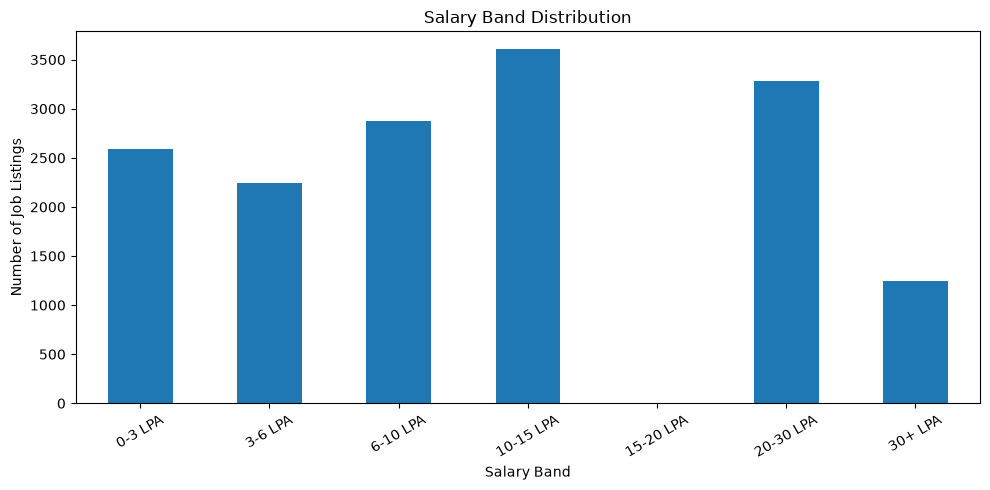

In [84]:
plt.figure(figsize=(10, 5))

salary_band_distribution.plot(kind="bar")

plt.title("Salary Band Distribution")
plt.xlabel("Salary Band")
plt.ylabel("Number of Job Listings")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Import ML libraries

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
f1_score, classification_report, ConfusionMatrixDisplay)

print("Machine learning libraries imported successfully.")

Machine learning libraries imported successfully.


### Select features

In [86]:
X = ml_data[["job_desig", "location", "key_skills", "min_experience_years"]]

y = ml_data["salary_band"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,job_desig,location,key_skills,min_experience_years
0,Oracle EBS Technical Consultant,"Bengaluru, Chennai","Oracle SQL, PLSQL, PL, Oracle Forms, Oracle Re...",6
1,Staff Software Engineer - Object Oriented Anal...,Bengaluru,"Javascript, HTML, JQuery, Web Development, Pla...",8
2,Servicenow Developer,"Hyderabad, Pune","SNOW, Servicenow, Servicenow Developer",3
3,"Software Development Engineering, Analyst",Pune,"QTP, Flex, LAN, Application support, Performan...",3
4,NVH Engineer - Nastran/ Ls-dyna,"Mumbai, Bengaluru, Hyderabad, Pune, Delhi","HyperMesh, LS - DYNA, NASTRAN, Abaqus, Fatigue...",5



Target:


0     6-10 LPA
1    10-15 LPA
2      0-3 LPA
3     6-10 LPA
4    10-15 LPA
Name: salary_band, dtype: category
Categories (7, str): ['0-3 LPA' < '3-6 LPA' < '6-10 LPA' < '10-15 LPA' < '15-20 LPA' < '20-30 LPA' < '30+ LPA']

### Train/test split

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 12672
Testing rows: 3169


### Build preprocessing pipeline

In [88]:
categorical_features = ["job_desig", "location", "key_skills"]

numerical_features = ["min_experience_years"]

preprocessor = ColumnTransformer(transformers=[
    ("categorical", Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),
                                    ("encoder",OneHotEncoder(handle_unknown="ignore"))]), 
     categorical_features), ("numerical", SimpleImputer(strategy="median"), numerical_features)])

## Random Forest model

In [89]:
rf_model = Pipeline(steps=[("preprocessor", preprocessor),("classifier", RandomForestClassifier(
    n_estimators=300, random_state=42, class_weight="balanced", n_jobs=-1))])
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Predictions

In [90]:
y_pred = rf_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


## Model Evaluation

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score

Because salary-band classes may not have equal representation, macro
averaging is included to give each class equal importance.

In [91]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average="macro", zero_division=0)

recall = recall_score(y_test, y_pred, average="macro", zero_division=0)

f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

model_metrics = pd.DataFrame({"Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"],
                              "Score": [accuracy, precision, recall, f1]})

model_metrics["Score"] = (model_metrics["Score"].round(4))

display(model_metrics)

,Metric,Score
0,Accuracy,0.3613
1,Macro Precision,0.3796
2,Macro Recall,0.3532
3,Macro F1,0.3575


### Classification report

In [92]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

     0-3 LPA       0.55      0.65      0.60       519
   10-15 LPA       0.30      0.38      0.34       722
   20-30 LPA       0.34      0.35      0.34       656
     3-6 LPA       0.34      0.20      0.25       448
     30+ LPA       0.50      0.30      0.37       249
    6-10 LPA       0.25      0.24      0.24       575

    accuracy                           0.36      3169
   macro avg       0.38      0.35      0.36      3169
weighted avg       0.36      0.36      0.35      3169



### Confusion matrix

<Figure size 1000x800 with 0 Axes>

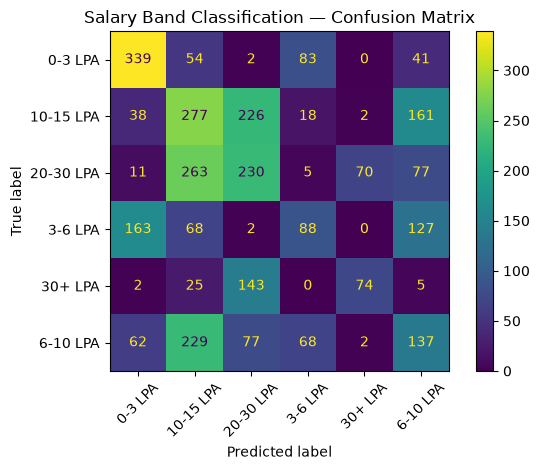

In [93]:
plt.figure(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=45)

plt.title("Salary Band Classification — Confusion Matrix")

plt.tight_layout()
plt.show()

### Feature importance

In [94]:
rf_classifier = (rf_model.named_steps["classifier"])

feature_names = (rf_model.named_steps["preprocessor"].get_feature_names_out())

feature_importance = pd.DataFrame({"feature": feature_names,"importance": rf_classifier.feature_importances_})

feature_importance = (feature_importance.sort_values("importance",ascending=False))

display(feature_importance.head(25))

,feature,importance
19313,numerical__min_experience_years,0.121801
8696,categorical__location_Bengaluru,0.005011
9422,categorical__location_Mumbai,0.002717
9270,"categorical__location_Gurgaon, Gurugram",0.002441
9245,categorical__location_Gurgaon,0.002154
9110,"categorical__location_Delhi NCR, Gurgaon",0.001597
1116,categorical__job_desig_Business Analyst,0.001544
9014,categorical__location_Delhi NCR,0.001300
9647,categorical__location_Pune,0.001173
2113,categorical__job_desig_Data Scientist,0.001131


### Feature importance visualization

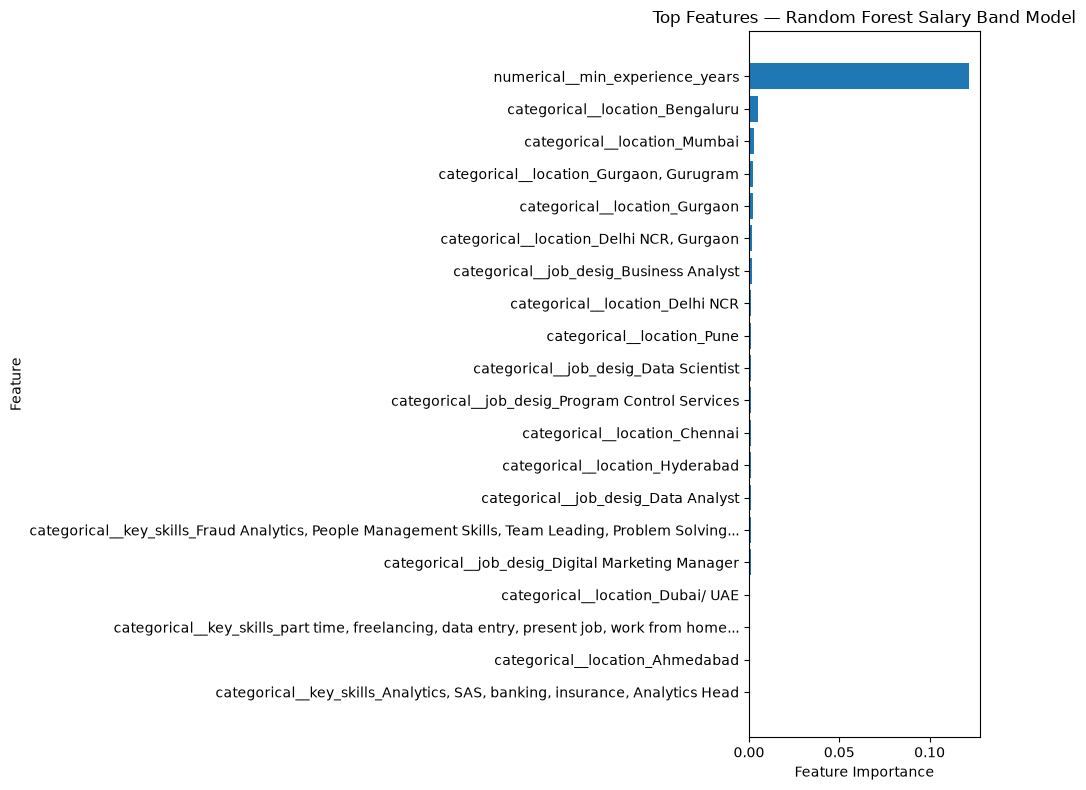

In [95]:
top_features = (feature_importance.head(20).sort_values("importance"))

plt.figure(figsize=(10, 8))

plt.barh(top_features["feature"], top_features["importance"])

plt.title("Top Features — Random Forest Salary Band Model")

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Machine Learning Limitations

The model has several limitations:

- The dataset represents observed job listings rather than the entire
  employment market.
- Salary values are reported as ranges or estimated values.
- Job descriptions and skill labels may contain inconsistent terminology.
- The model identifies associations within the dataset and does not prove
  causal relationships.
- The model should not be used to make individual employment or
  compensation decisions.
- Performance may change when evaluated on a different job market or
  time period.

## Model Comparison

A simple baseline model is compared with the Random Forest classifier.

The purpose is to determine whether the more flexible Random Forest model
provides meaningful improvement over a simple benchmark.

The comparison uses the same train/test split and evaluation metrics.

### Create a baseline

In [96]:
from sklearn.dummy import DummyClassifier

baseline_model = DummyClassifier(strategy="most_frequent")

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

print("Baseline model trained successfully.")

Baseline model trained successfully.


### Evaluate the baseline

In [97]:
baseline_accuracy = accuracy_score(y_test, baseline_pred)

baseline_precision = precision_score(y_test, baseline_pred, average="macro", zero_division=0)

baseline_recall = recall_score(y_test, baseline_pred, average="macro", zero_division=0)

baseline_f1 = f1_score(y_test, baseline_pred, average="macro", zero_division=0)

baseline_metrics = pd.DataFrame({"Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"],
                                 "Score": [baseline_accuracy, baseline_precision, baseline_recall, baseline_f1]})

baseline_metrics["Score"] = (baseline_metrics["Score"].round(4))

display(baseline_metrics)

,Metric,Score
0,Accuracy,0.2278
1,Macro Precision,0.0380
2,Macro Recall,0.1667
3,Macro F1,0.0619


## Compare both models

In [98]:
model_comparison = pd.DataFrame({"Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"],
                                 "Baseline": [baseline_accuracy, baseline_precision, baseline_recall, baseline_f1],
                                 "Random Forest": [accuracy, precision, recall, f1]})

model_comparison["Improvement"] = (model_comparison["Random Forest"] - model_comparison["Baseline"])

model_comparison = model_comparison.round(4)

display(model_comparison)

,Metric,Baseline,Random Forest,Improvement
0,Accuracy,0.2278,0.3613,0.1335
1,Macro Precision,0.0380,0.3796,0.3417
2,Macro Recall,0.1667,0.3532,0.1866
3,Macro F1,0.0619,0.3575,0.2957


### Model Performance Comparison

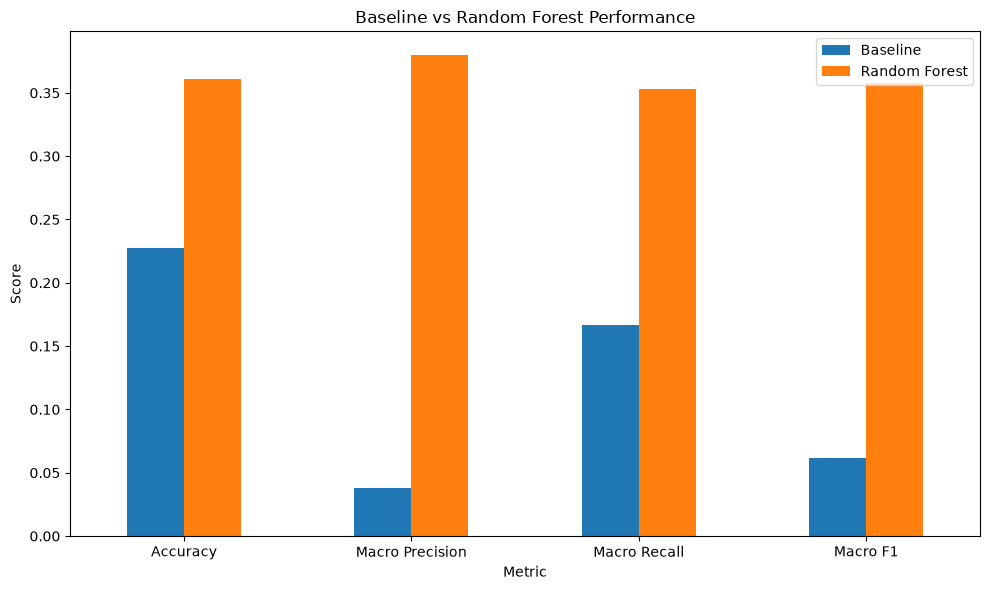

In [99]:
comparison_plot = model_comparison.set_index("Metric")[["Baseline", "Random Forest"]]

comparison_plot.plot(kind="bar",figsize=(10, 6))

plt.title("Baseline vs Random Forest Performance")

plt.ylabel("Score")
plt.xlabel("Metric")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Calculate improvement

In [100]:
rf_f1_improvement = (f1 - baseline_f1)

rf_accuracy_improvement = (accuracy - baseline_accuracy)

print(f"Accuracy improvement: "f"{rf_accuracy_improvement:.4f}")

print(f"Macro F1 improvement: "f"{rf_f1_improvement:.4f}")

Accuracy improvement: 0.1335
Macro F1 improvement: 0.2957


### Determine whether Random Forest adds value

In [101]:
if rf_f1_improvement > 0:model_verdict = ("Random Forest improves Macro F1 over "
                                          "the baseline on this test set.")
else:
    model_verdict = ("Random Forest does not improve Macro F1 "
                     "over the baseline on this test set.")

print(model_verdict)

Random Forest improves Macro F1 over the baseline on this test set.


## Model Interpretation

The Random Forest model is compared against a majority-class baseline.

The baseline establishes the minimum level of performance that a useful
classifier should exceed.

If Random Forest improves Macro F1 and other evaluation metrics, this
suggests that the supplied job-market features contain information useful
for distinguishing observed salary bands.

However, this does not establish causal relationships between skills,
roles, experience, and salary.

### ML quality checks

In [102]:
print("=" * 70)
print("ML QUALITY CHECK")
print("=" * 70)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nNumber of salary bands:", y.nunique())

print("\nBaseline Macro F1:", round(baseline_f1, 4))
print("Random Forest Macro F1:", round(f1, 4))

print("\nRandom Forest improves over baseline:", f1 > baseline_f1)

print("\nFeature importance generated:", not feature_importance.empty)

print("\nML QUALITY CHECK COMPLETE")

ML QUALITY CHECK

Training samples: 12672
Testing samples: 3169

Number of salary bands: 6

Baseline Macro F1: 0.0619
Random Forest Macro F1: 0.3575

Random Forest improves over baseline: True

Feature importance generated: True

ML QUALITY CHECK COMPLETE


## Career Intelligence Engine

The Career Intelligence Engine consolidates the analytical findings into
a structured market-oriented summary.

It focuses on observed job-market signals rather than making individual
employment or salary decisions.

### Build the top-demand role table

In [103]:
career_roles = (role_demand_filtered.sort_values("job_listings", ascending=False)
    .head(10).reset_index())

career_roles

,job_desig,job_listings,average_salary_lpa,median_salary_lpa,average_min_experience
0,Business Analyst,108,9.111111,8.0,3.287037
1,Data Scientist,64,13.3125,12.5,3.609375
2,Data Analyst,50,8.38,8.0,3.18
3,Digital Marketing Manager,45,8.377778,8.0,3.866667
4,Home Base Job/ Data Entry/online Work/part Tim...,45,3.033333,4.5,0.044444
5,Product Manager,44,13.909091,12.5,3.954545
6,Digital Marketing Executive,36,3.388889,3.0,1.416667
7,Analyst,35,8.1,8.0,3.485714
8,SEO Executive,29,3.948276,4.5,1.206897
9,SEO Analyst,26,4.307692,4.5,1.423077


### Build the top-salary role table

In [104]:
career_salary_roles = (role_demand_filtered.sort_values("average_salary_lpa", ascending=False)
    .head(10).reset_index())

career_salary_roles

,job_desig,job_listings,average_salary_lpa,median_salary_lpa,average_min_experience
0,Associate Vice President - Fraud Analytics - S...,13,37.5,37.5,10.230769
1,Associate Vice President - Analytics - SAS - Bank,13,36.153846,37.5,9.769231
2,Senior Manager - Retail Analytics - Analytics ...,13,34.807692,37.5,9.769231
3,Trading Head - Market Making/high Frequency Tr...,11,28.454545,37.5,5.545455
4,Assistant Vice President - Insurance Analytics,10,27.0,20.0,8.8
5,Technical Manager,11,26.363636,20.0,8.636364
6,Quantitative Analyst - HFT,10,23.75,20.0,5.1
7,Financial Controller,10,21.0,20.0,5.3
8,Manager - Supply Chain Analytics - Consulting ...,10,18.8,20.0,8.0
9,Analytics Manager,13,18.769231,20.0,5.846154


### Build the company intelligence table

In [105]:
career_companies = (company_signal.head(15).reset_index())

career_companies

,company_name,total_job_demand,average_salary_lpa,maximum_salary_lpa,minimum_salary_lpa,demand_score,salary_score,market_signal_score
0,TCS,9064,9.46,30.0,2.4,1.000000,0.249824,0.69993
1,Accenture,5425,12.19,33.0,2.3,0.598522,0.321919,0.487881
2,Microsoft Corporation,127,37.866667,100.0,13.0,0.014011,1.0,0.408407
3,Cognizant,3813,11.21,25.5,2.9,0.420675,0.296039,0.370821
4,Fidelity International,44,33.25,93.0,13.5,0.004854,0.878081,0.354145
5,Innova Solutions,17,33.4,97.0,6.0,0.001876,0.882042,0.353942
6,PepsiCo,11,31.55,49.0,19.0,0.001214,0.833187,0.334003
7,Uber,76,30.9,93.0,6.5,0.008385,0.816021,0.331439
8,Expedia,18,31.2,41.3,20.0,0.001986,0.823944,0.330769
9,Koch Business Solutions,41,30.9,51.0,12.0,0.004523,0.816021,0.329122


### Create executive summary metrics

In [106]:
executive_summary = {"total_analytics_job_listings": int(len(analytics_clean)),
                     "total_data_science_records": int(len(data_science_clean)),
                     "unique_analytics_roles": int(analytics_clean["job_desig"].nunique()),
                     "unique_locations": int(analytics_clean["location"].nunique()),
                     "unique_data_science_companies": int(data_science_clean["company_name"].nunique()),
                     "top_analytics_role": (top_roles_by_demand.index[0]),
                     "top_data_science_company": (top_ds_companies.index[0]),
                     "top_salary_role": (top_roles_by_salary.index[0])}

executive_summary

{'total_analytics_job_listings': 15841,
 'total_data_science_records': 1602,
 'unique_analytics_roles': 10096,
 'unique_locations': 1355,
 'unique_data_science_companies': 642,
 'top_analytics_role': 'Business Analyst',
 'top_data_science_company': 'TCS',
 'top_salary_role': 'Associate Vice President - Fraud Analytics - SAS - Bank'}

## Executive Career Intelligence Report

The following report summarizes the main findings from the job-market
analysis.

In [107]:
print("=" * 80)
print("JOB MARKET & CAREER INTELLIGENCE REPORT")
print("=" * 80)

print("\nMARKET OVERVIEW")
print("-" * 80)

print(f"Analytics job listings analyzed: "f"{executive_summary['total_analytics_job_listings']:,}")

print(f"Data Science records analyzed: "f"{executive_summary['total_data_science_records']:,}")

print(f"Unique Analytics roles: "f"{executive_summary['unique_analytics_roles']:,}")

print(f"Unique locations: "f"{executive_summary['unique_locations']:,}")

print(f"Data Science companies: "f"{executive_summary['unique_data_science_companies']:,}")

print("\nKEY MARKET SIGNALS")
print("-" * 80)

print(f"Top Analytics role by listing volume: "f"{executive_summary['top_analytics_role']}")

print(f"Top Data Science company by job volume: "f"{executive_summary['top_data_science_company']}")

print(f"Highest average salary role among filtered roles: "f"{executive_summary['top_salary_role']}")

JOB MARKET & CAREER INTELLIGENCE REPORT

MARKET OVERVIEW
--------------------------------------------------------------------------------
Analytics job listings analyzed: 15,841
Data Science records analyzed: 1,602
Unique Analytics roles: 10,096
Unique locations: 1,355
Data Science companies: 642

KEY MARKET SIGNALS
--------------------------------------------------------------------------------
Top Analytics role by listing volume: Business Analyst
Top Data Science company by job volume: TCS
Highest average salary role among filtered roles: Associate Vice President - Fraud Analytics - SAS - Bank


### Create career recommendations

In [108]:
top_skill_names = (career_skill.head(10)["skill"].tolist())

top_role_names = (career_roles["job_desig"].head(5).tolist())

top_company_names = (career_companies["company_name"].head(10).tolist())

career_recommendations = [{"Area": "Skill Development","Recommendation": (
    "Prioritize skills with strong observed job-market demand "
    "and meaningful representation across target roles.")}, 
                          {"Area": "Role Targeting","Recommendation": (
                              "Prioritize roles that combine strong listing volume with "
                              "skills aligned to your career profile.")},
                          {"Area": "Company Targeting","Recommendation": (
                              "Track companies showing substantial Data Science hiring "
                              "volume and relevant salary signals.")},
                          {"Area": "Experience Planning","Recommendation": (
                              "Compare experience requirements across target roles before "
                              "setting short-term career goals.")}]

recommendations_df = pd.DataFrame(career_recommendations)

display(recommendations_df)

,Area,Recommendation
0,Skill Development,Prioritize skills with strong observed job-mar...
1,Role Targeting,Prioritize roles that combine strong listing v...
2,Company Targeting,Track companies showing substantial Data Scien...
3,Experience Planning,Compare experience requirements across target ...


### Show the actual evidence behind recommendations

In [109]:
print("Top observed skills:")
print(", ".join(top_skill_names))

print("\nTop observed Analytics roles:")
print(", ".join(top_role_names))

print("\nCompanies with strong observed Data Science job demand/signal:")
print(", ".join(top_company_names))

Top observed skills:
..., analytics, sql, python, finance, java, r, sas, machine learning, business analysis

Top observed Analytics roles:
Business Analyst, Data Scientist, Data Analyst, Digital Marketing Manager, Home Base Job/ Data Entry/online Work/part Time Work/freelancer work

Companies with strong observed Data Science job demand/signal:
TCS, Accenture, Microsoft Corporation, Cognizant, Fidelity International, Innova Solutions, PepsiCo, Uber, Expedia, Koch Business Solutions


### ML finding

In [110]:
print("\nMACHINE LEARNING SIGNAL")
print("-" * 80)

print(f"Baseline Macro F1: {baseline_f1:.4f}")

print(f"Random Forest Macro F1: {f1:.4f}")

print(f"Random Forest improvement: "f"{rf_f1_improvement:.4f}")

print(f"\nModel conclusion: {model_verdict}")


MACHINE LEARNING SIGNAL
--------------------------------------------------------------------------------
Baseline Macro F1: 0.0619
Random Forest Macro F1: 0.3575
Random Forest improvement: 0.2957

Model conclusion: Random Forest improves Macro F1 over the baseline on this test set.


### Career Intelligence Dashboard Table

In [111]:
career_dashboard = pd.DataFrame({"Intelligence Area": ["Top Analytics Role", "Top Data Science Hiring Company",
                                                       "Highest Salary Role", "Top Observed Skill",
                                                       "Analytics Job Listings", "Data Science Records",
                                                       "Random Forest Macro F1"],
                                 "Result": [executive_summary["top_analytics_role"],
                                            executive_summary["top_data_science_company"],
                                            executive_summary["top_salary_role"],top_skill_names[0],
                                            executive_summary["total_analytics_job_listings"],
                                            executive_summary["total_data_science_records"],round(f1, 4)]})

display(career_dashboard)

,Intelligence Area,Result
0,Top Analytics Role,Business Analyst
1,Top Data Science Hiring Company,TCS
2,Highest Salary Role,Associate Vice President - Fraud Analytics - S...
3,Top Observed Skill,...
4,Analytics Job Listings,15841
5,Data Science Records,1602
6,Random Forest Macro F1,0.3575


## Responsible Interpretation

The Career Intelligence Engine provides descriptive insights from the
available job-market datasets.

The results should be used to support research and career planning, not
as guarantees of employment, compensation, or hiring outcomes.

The analysis does not establish that a particular skill, company, role,
or experience level causes a specific salary outcome.

The machine-learning model identifies statistical patterns within the
available data and should not be used for automated employment decisions.

## Key Takeaway

The project demonstrates how job-market data can be transformed into
career intelligence through a combination of:

- Exploratory Data Analysis
- Skill Mining
- Role-Skill Analysis
- Salary Analysis
- Company Analysis
- Machine Learning
- Model Evaluation

The resulting framework can help analysts and job seekers understand
observed market patterns and prioritize areas for further investigation.

## Final Portfolio Visualizations

In [112]:
FIGURE_DIR = PROJECT_DIR / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Figure directory:", FIGURE_DIR)

Figure directory: C:\Users\Dell\Downloads\DSAI-Portfolio\04-job-market-intelligence\outputs\figures


### Top Job Roles

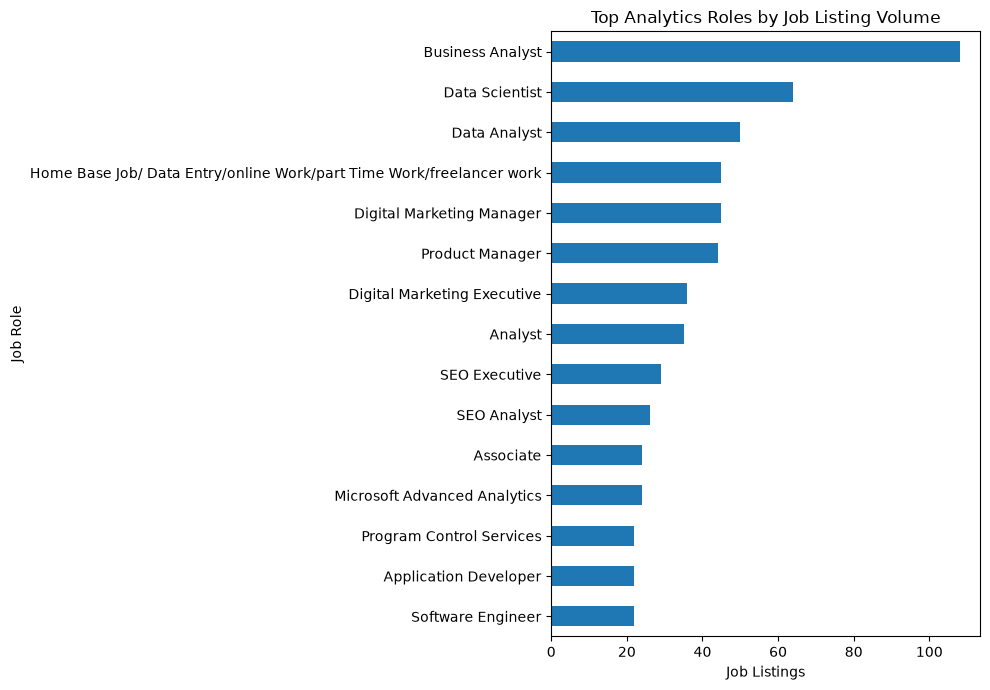

In [113]:
plt.figure(figsize=(10, 7))

top_roles_by_demand["job_listings"].sort_values().plot(kind="barh")

plt.title("Top Analytics Roles by Job Listing Volume")
plt.xlabel("Job Listings")
plt.ylabel("Job Role")

plt.tight_layout()

plt.savefig(FIGURE_DIR / "01_top_analytics_roles.png", dpi=300, bbox_inches="tight")

plt.show()

### Top Data Science Hiring Companies

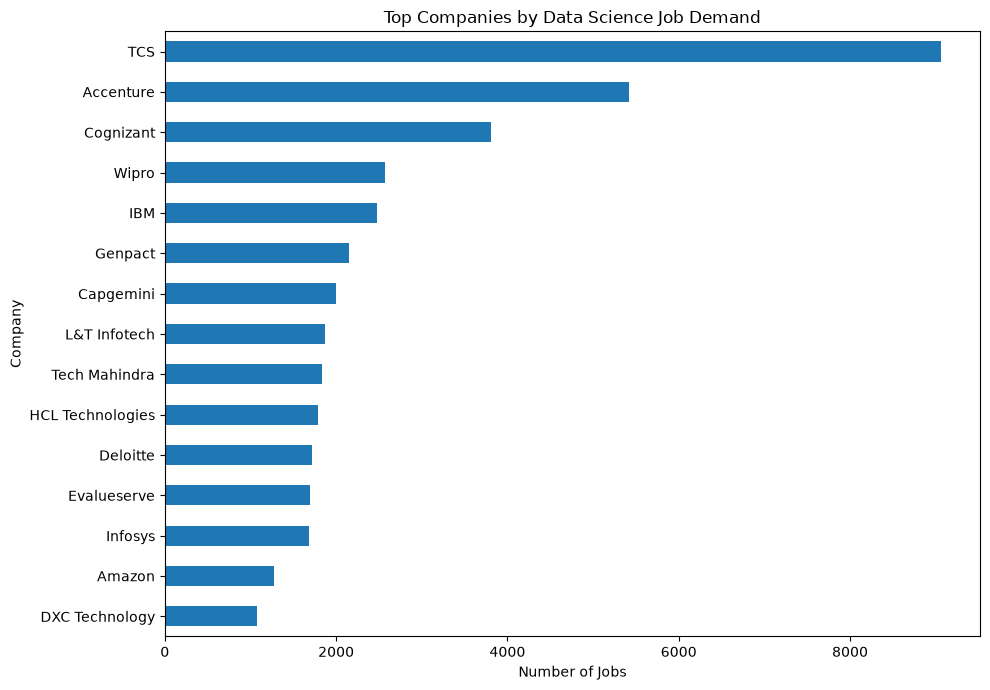

In [114]:
plt.figure(figsize=(10, 7))

top_ds_companies.sort_values().plot(kind="barh")

plt.title("Top Companies by Data Science Job Demand")
plt.xlabel("Number of Jobs")
plt.ylabel("Company")

plt.tight_layout()

plt.savefig(FIGURE_DIR / "02_top_data_science_companies.png",dpi=300,bbox_inches="tight")

plt.show()

### Top Skills

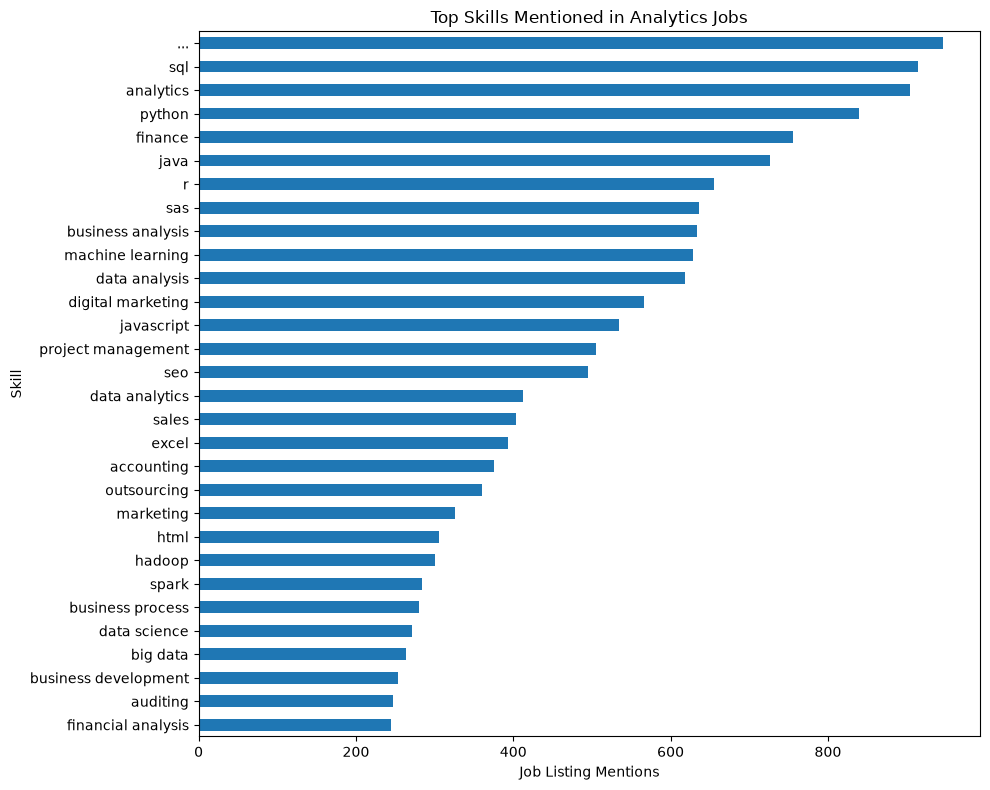

In [115]:
plt.figure(figsize=(10, 8))

top_skills.sort_values().plot(kind="barh")

plt.title("Top Skills Mentioned in Analytics Jobs")
plt.xlabel("Job Listing Mentions")
plt.ylabel("Skill")

plt.tight_layout()

plt.savefig(FIGURE_DIR / "03_top_analytics_skills.png",dpi=300,bbox_inches="tight")

plt.show()

### Demand vs Salary

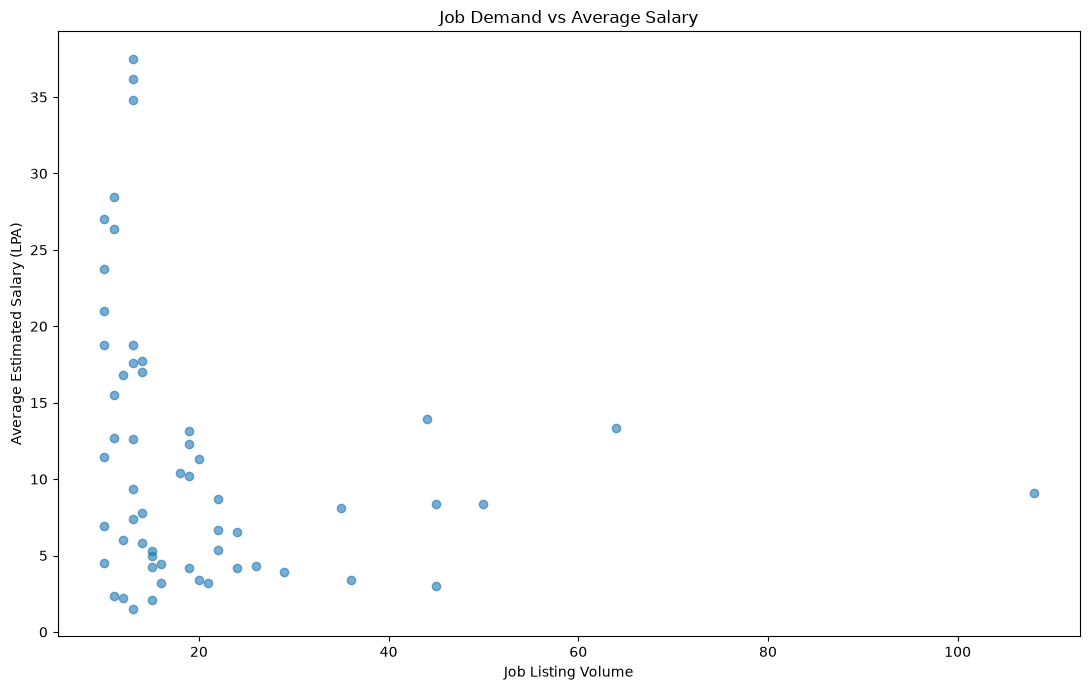

In [116]:
plt.figure(figsize=(11, 7))

plt.scatter(role_demand_filtered["job_listings"], role_demand_filtered["average_salary_lpa"], alpha=0.6)

plt.xlabel("Job Listing Volume")
plt.ylabel("Average Estimated Salary (LPA)")
plt.title("Job Demand vs Average Salary")

plt.tight_layout()

plt.savefig(FIGURE_DIR / "04_job_demand_vs_salary.png", dpi=300, bbox_inches="tight")

plt.show()

### Salary Band Model Performance

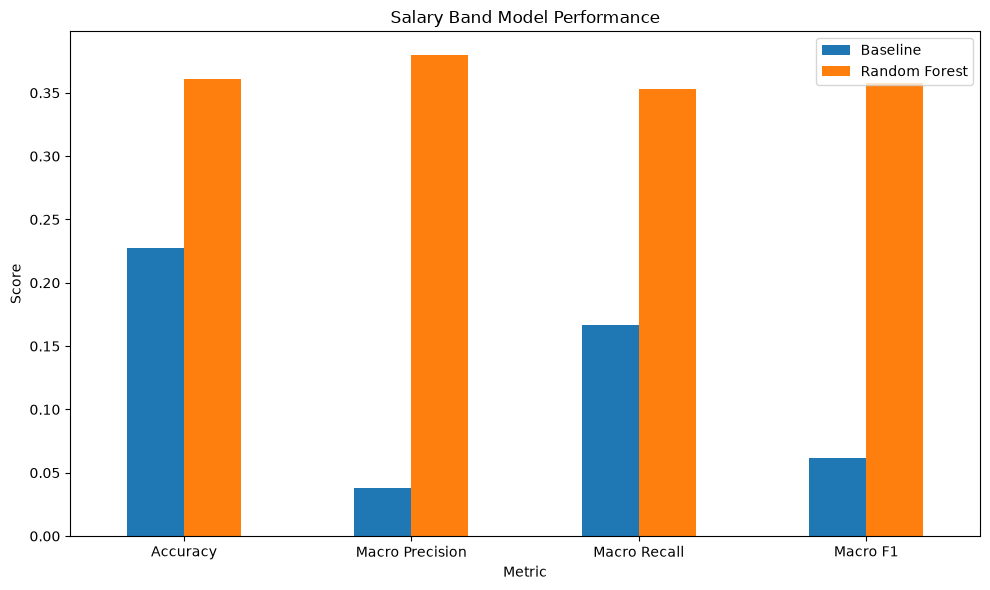

In [117]:
model_plot = model_comparison.set_index("Metric")[["Baseline", "Random Forest"]]

model_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Salary Band Model Performance")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(FIGURE_DIR / "05_model_performance.png", dpi=300, bbox_inches="tight")

plt.show()

### Feature Importance

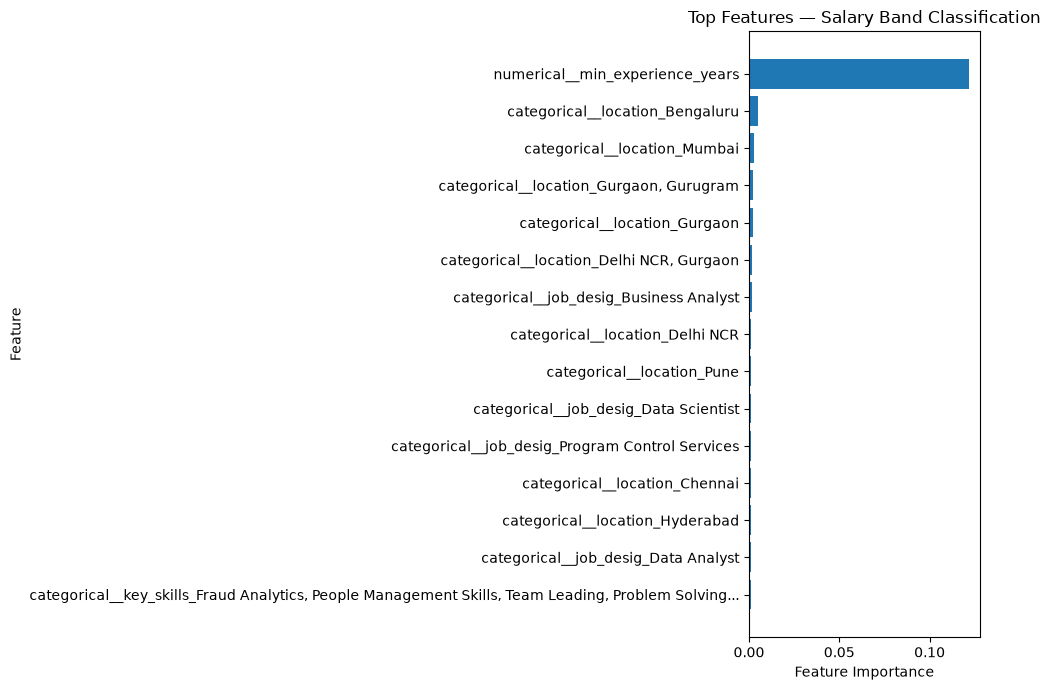

In [118]:
top_features = (feature_importance.head(15).sort_values("importance"))

plt.figure(figsize=(10, 7))

plt.barh(top_features["feature"], top_features["importance"])

plt.title("Top Features — Salary Band Classification")

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(FIGURE_DIR / "06_salary_model_feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

### Verify all final figures

In [119]:
print("=" * 70)
print("FINAL FIGURE QA")
print("=" * 70)

figure_files = sorted(FIGURE_DIR.glob("*.png"))

for file in figure_files:
    print("-", file.name)

print("\nTotal figures:", len(figure_files))

FINAL FIGURE QA
- 01_top_analytics_roles.png
- 02_top_data_science_companies.png
- 03_top_analytics_skills.png
- 04_job_demand_vs_salary.png
- 05_model_performance.png
- 06_salary_model_feature_importance.png

Total figures: 6


## Final Project QA

In [120]:
print("=" * 80)
print("JOB MARKET & CAREER INTELLIGENCE — FINAL QA")
print("=" * 80)

print("\nDATASETS")
print("Analytics:", analytics_clean.shape)
print("Data Science:", data_science_clean.shape)

print("\nEDA")
print("Analytics roles:", analytics_clean["job_desig"].nunique())
print("Analytics locations:", analytics_clean["location"].nunique())
print("Data Science companies:", data_science_clean["company_name"].nunique())

print("\nSKILL INTELLIGENCE")
print("Unique extracted skills:", skills_long.nunique())

print("\nMACHINE LEARNING")
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Random Forest Accuracy:", round(accuracy, 4))
print("Random Forest Macro F1:", round(f1, 4))

print("\nCAREER INTELLIGENCE")
print("Top Analytics Role:", executive_summary["top_analytics_role"])
print("Top Data Science Company:", executive_summary["top_data_science_company"])
print("Highest Salary Role:", executive_summary["top_salary_role"])

print("\nFIGURES")

figure_files = sorted(FIGURE_DIR.glob("*.png"))

for file in figure_files:
    print("-", file.name)

print("\nTotal figures:", len(figure_files))

print("\nFINAL QA COMPLETE")

JOB MARKET & CAREER INTELLIGENCE — FINAL QA

DATASETS
Analytics: (15841, 13)
Data Science: (1602, 12)

EDA
Analytics roles: 10096
Analytics locations: 1355
Data Science companies: 642

SKILL INTELLIGENCE
Unique extracted skills: 10658

MACHINE LEARNING
Training rows: 12672
Testing rows: 3169
Random Forest Accuracy: 0.3613
Random Forest Macro F1: 0.3575

CAREER INTELLIGENCE
Top Analytics Role: Business Analyst
Top Data Science Company: TCS
Highest Salary Role: Associate Vice President - Fraud Analytics - SAS - Bank

FIGURES
- 01_top_analytics_roles.png
- 02_top_data_science_companies.png
- 03_top_analytics_skills.png
- 04_job_demand_vs_salary.png
- 05_model_performance.png
- 06_salary_model_feature_importance.png

Total figures: 6

FINAL QA COMPLETE
